# ThemeCloner
**Find undiscovered thematic exposure in small caps using RP-PCA on residualized returns.**

## Architecture

| Component | Role | Data source |
|-----------|------|-------------|
| ETF returns | Theme definition + OOS validation | yfinance (BOTZ, ICLN, AINF.L etc.) |
| Covariance universe | RP-PCA factor extraction (on residuals) | US-only: SP500 + NASDAQ/NYSE mid-small (~1000 stocks) |
| FF5 + momentum factors | Stripped from returns before RP-PCA | Kenneth French data library |
| Target universe | Where we hunt for alpha | Russell 2000 proxy with metadata filter |

## Why residualize first
Without residualization, RP-PCA's largest factor absorbs market beta + growth + momentum, which makes any high-momentum stock (like TWST in 2020-2021) score highly on every theme. Residualizing against FF5+momentum first ensures whatever survives in the latent factors is genuinely thematic co-movement, not factor exposure dressed up as a theme. This directly addresses the industry critique that **thematic investing is just momentum with a story**.

## Data limitations (documented for paper)
- MSCI ACWI constituents require vendor licence → proxied with free index lists
- ETF constituent holdings blocked by providers → ETF price series used as theme labels
- Russell 2000 full list requires FTSE Russell licence → metadata-filtered NASDAQ+NYSE ex-SP500

**Note on covariance universe scope:** US-only by default to avoid FX co-movement and London/Tokyo vs US close timing artifacts contaminating factor structure. The thematic ETFs themselves (ICLN, IRBO) can still hold global stocks since they only serve as theme labels. Toggle via `us_only=False` in `pull_covariance_universe()` if you address timing/FX issues separately.

Edit `config/etfs.csv` to change themes and ETFs.

In [1]:
# -------------------- 0. Setup --------------------

import sys, os

# make sure we run from the ThemeCloner root regardless of where Jupyter launched
ROOT = os.path.abspath(os.path.join(os.getcwd()))
if not os.path.exists(os.path.join(ROOT, 'config', 'etfs.csv')):
    ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(ROOT)
sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

print(f'root: {ROOT}')
print(f'config exists: {os.path.exists("config/etfs.csv")}')
print('setup done')

root: C:\Users\aamin\Thematic Engine
config exists: True
setup done


## Step 1 — Pull Data

In [2]:
# -------------------- 1a. Load ETF config --------------------

from src.data_pull import (load_etf_config, pull_etf_returns,
                            pull_covariance_universe, pull_target_universe)

# parameters -- tune these for the run
START_DATE  = '2018-01-01'
K           = 15     # factors for covariance universe RP-PCA (more themes need more K)
GAMMA       = 10.0   # Lettau-Pelger default
TOP_N       = 30     # candidates per theme
MIN_SCORE   = 0.40   # minimum cosine similarity to be a candidate
TOP_FACTORS = 3      # how many factors per ETF to use for theme fingerprint
RESIDUALIZE_MOMENTUM = False  # False = strip FF5 only (keep momentum)
INCLUDE_COMMODITY    = False  # EXPERIMENT 1: True = also strip commodity beta
                              # (DBC/DBE/DBB/GLD/DBA) to test if it rescues
                              # Clean Energy / Agribusiness from commodity contamination

etf_config = load_etf_config('config/etfs.csv')
etf_config


# split discovery themes from calibration controls (sector/subsector)
from src.data_pull import split_themes_controls
themes_config, controls_config = split_themes_controls(etf_config)
print(f'\n{len(themes_config["theme"].unique())} discovery themes, '
      f'{len(controls_config["theme"].unique())} calibration controls')

loaded 44 ETFs: 31 theme-ETFs, 13 control-ETFs (sector/subsector calibration anchors)
  AI Infrastructure: IGPT (IGPT), QTUM (QTUM), SOXX (SOXX)
  Agribusiness: MOO (MOO), VEGI (VEGI), PBJ (PBJ)
  Clean Energy: ICLN (ICLN), QCLN (QCLN), PBW (PBW)
  Critical Minerals: URA (URA), LIT (LIT), COPX (COPX)
  Cybersecurity: CIBR (CIBR), HACK (HACK), BUG (BUG)
  Defense: ITA (ITA), PPA (PPA), XAR (XAR)
  Factor1: IUSG (IUSG)
  Factor2: VLUE (VLUE)
  Factor3: QUAL (QUAL)
  Factor4: SPGP (SPGP)
  Factor5: MTUM (MTUM)
  Factor6: VUG (VUG)
  Factor7: VTV (VTV)
  Fintech: FINX (FINX), ARKF (ARKF), IPAY (IPAY)
  Robotics & AI: BOTZ (BOTZ), ROBO (ROBO), IRBO (IRBO)
  SECTOR: US Energy: XLE (XLE)
  SECTOR: US Financials: XLF (XLF)
  SECTOR: US Technology: XLK (XLK)
  SUBSECTOR: US Banks: KRE (KRE)
  SUBSECTOR: US Biotech: XBI (XBI)
  SUBSECTOR: US Software: IGV (IGV)
  Timber & Forestry: WOOD (WOOD), CUT (CUT)
  US Infrastructure: PAVE (PAVE), IFRA (IFRA)
  Water: PHO (PHO), FIW (FIW), CGW (CGW)

11 d

In [3]:
# -------------------- 1b. Pull ETF returns --------------------
# these serve two roles: theme definition (labeling factors) and OOS validation

etf_returns = pull_etf_returns(etf_config, start=START_DATE)
etf_returns.tail(3)


pulling ETF panel: 44 tickers in 1 batch(es)
  batch 1/1 (44 tickers)...
  dropped 1 tickers below 85% coverage
  ETF panel: 444 weeks x 43 stocks
  date range: 2018-01-12 to 2026-07-10
  ETFs kept: ['ARKF', 'BOTZ', 'CGW', 'CIBR', 'COPX', 'CUT', 'FINX', 'FIW', 'HACK', 'ICLN', 'IFRA', 'IGPT', 'IGV', 'IPAY', 'IRBO', 'ITA', 'IUSG', 'KRE', 'LIT', 'MOO', 'MTUM', 'PAVE', 'PBJ', 'PBW', 'PHO', 'PPA', 'QCLN', 'QTUM', 'QUAL', 'ROBO', 'SOXX', 'SPGP', 'URA', 'VEGI', 'VLUE', 'VTV', 'VUG', 'WOOD', 'XAR', 'XBI', 'XLE', 'XLF', 'XLK']


,ARKF,BOTZ,CGW,CIBR,COPX,CUT,FINX,FIW,HACK,ICLN,...,VEGI,VLUE,VTV,VUG,WOOD,XAR,XBI,XLE,XLF,XLK
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-26,-0.020952,-0.063479,0.032378,0.010512,-0.115184,0.008190,-0.002807,0.033043,0.027230,-0.078859,...,0.014283,0.000850,0.013611,-0.048625,-0.007160,-0.036320,0.100083,0.008487,0.003497,-0.054278
2026-07-03,0.044163,0.038107,0.003196,0.060349,0.009543,0.002125,0.028280,-0.003937,0.080970,0.008680,...,0.010693,-0.036233,0.003565,0.032571,-0.000899,0.047975,0.032171,-0.011582,0.037554,-0.002875
2026-07-10,0.011648,-0.020536,-0.017474,0.038830,-0.016442,-0.022820,0.001954,-0.017678,0.044878,-0.017436,...,-0.012524,0.010978,-0.002787,0.017162,-0.004463,-0.048705,0.023528,0.029621,-0.001439,0.026017


In [4]:
# -------------------- 1c. Pull covariance universe (ACWI proxy) --------------------
# this is what RP-PCA runs on -- needs to be broad enough to capture all themes
# SP500 + SP400 + SP600 + STOXX600 + Nikkei225
# first run: ~10-15 min to pull. subsequent runs use cache.

cov_returns = pull_covariance_universe(start=START_DATE, use_cache=True, us_only=True)
print(f'covariance universe: {cov_returns.shape[1]} stocks x {cov_returns.shape[0]} weeks')

loaded covariance universe from cache (us_only): 1003 tickers across ['us_sp500', 'us_mid_small']

pulling covariance universe: 1003 unique tickers

pulling covariance universe: 1003 tickers in 3 batch(es)
  batch 1/3 (400 tickers)...
  batch 2/3 (400 tickers)...
  batch 3/3 (203 tickers)...
  dropped 249 tickers below 85% coverage
  covariance universe: 444 weeks x 754 stocks
  date range: 2018-01-12 to 2026-07-10
covariance universe: 754 stocks x 444 weeks


In [5]:
# -------------------- 1d. Pull target universe (Russell 2000 proxy) --------------------
# small caps we score for undiscovered thematic exposure
# first run: ~20-30 min. subsequent runs use cache.

from src.data_pull import _cached_returns, pull_target_universe

#tgt_returns = _cached_returns('target_universe_returns', pull_target_universe, refresh=True, start=START_DATE, use_cache=False)
tgt_returns = _cached_returns('target_universe_returns', pull_target_universe, refresh=False, start=START_DATE)

print(f'target universe: {tgt_returns.shape[1]} stocks x {tgt_returns.shape[0]} weeks')

  loaded target_universe_returns from cache: 444 weeks x 811 cols
target universe: 811 stocks x 444 weeks


## Step 1.5 — Residualize Returns Against FF5 + Momentum

In [6]:
# -------------------- 1.5. Residualize covariance universe AND ETF returns --------------------
# strip out market, size, value, profitability, investment, momentum
# what remains is co-movement that cannot be explained by standard factors
# this is THE key step that distinguishes thematic from momentum

from src.residualize import (residualize_universe, get_ff_factors,
                             residualize_returns, get_combined_factors)

# residualize the covariance universe
print('=' * 60)
print('RESIDUALIZING COVARIANCE UNIVERSE')
print('=' * 60)
# pull factors first so we can choose which to strip
# optionally include commodity controls (Experiment 1)
ff_factors = get_combined_factors(
    start=str(cov_returns.index[0].date()),
    end=str(cov_returns.index[-1].date()),
    freq='weekly', include_commodity=INCLUDE_COMMODITY)

# choose factor columns: FF5 always, momentum only if RESIDUALIZE_MOMENTUM=True
comm_cols = [c for c in ff_factors.columns if c.startswith('COMM_')]
if RESIDUALIZE_MOMENTUM:
    base_cols = [c for c in ff_factors.columns if c not in ('RF',) and not c.startswith('COMM_')]
    print('stripping FF5 + momentum')
else:
    base_cols = [c for c in ff_factors.columns if c not in ('RF', 'MOM') and not c.startswith('COMM_')]
    print('stripping FF5 ONLY (keeping momentum)')
resid_cols = base_cols + comm_cols
if comm_cols:
    print(f'  + commodity controls: {comm_cols}')

cov_residuals = residualize_returns(cov_returns, ff_factors, factor_cols=resid_cols)
print(f'covariance residuals: {cov_residuals.shape[0]} weeks x {cov_residuals.shape[1]} stocks')

# residualize ETF returns using the SAME factors
print('\n' + '=' * 60)
print('RESIDUALIZING ETF RETURNS')
print('=' * 60)
from src.residualize import residualize_returns
etf_residuals = residualize_returns(etf_returns, ff_factors, factor_cols=resid_cols)
print(f'ETF residuals: {etf_residuals.shape[0]} weeks x {etf_residuals.shape[1]} ETFs')

# residualize target universe too (will use raw for validation later)
print('\n' + '=' * 60)
print('RESIDUALIZING TARGET UNIVERSE')
print('=' * 60)
tgt_residuals = residualize_returns(tgt_returns, ff_factors, factor_cols=resid_cols)
print(f'target residuals: {tgt_residuals.shape[0]} weeks x {tgt_residuals.shape[1]} stocks')


# -------------------- standardize residuals to unit vol --------------------
# CRITICAL: without this, high-vol micro-caps dominate the PCA factors
# (crypto miners, biotech blow-ups have huge residual variance)
# standardizing makes it a correlation decomposition -- structure not amplitude
from src.residualize import standardize_residuals

print('\nstandardizing residuals...')
cov_residuals = standardize_residuals(cov_residuals)
etf_residuals = standardize_residuals(etf_residuals)
tgt_residuals = standardize_residuals(tgt_residuals)

RESIDUALIZING COVARIANCE UNIVERSE

pulling FF5 + momentum from Kenneth French library (weekly)...
  momentum fetch failed via pandas_datareader (Unknown datetime string format, unable to parse: Missing data are indicated by -99.99 or -999., at position 0)
  falling back to direct download from Ken French's data library...
  first 20 raw lines (for diagnosis):
    'This file was created by using the 202605 CRSP database.  It,,'
    'contains a momentum factor, constructed from six value-weight portfolios formed,'
    'using independent sorts on size and prior return of NYSE, AMEX, and NASDAQ stocks.'
    'MOM is the average of the returns on two (big and small) high prior return portfolios,,'
    'minus the average of the returns on two low prior return portfolios.  The portfolios,,'
    'are constructed daily.  Big means a firm is above the median market cap on the NYSE,,'
    'at the end of the previous day; small firms are below the median NYSE market cap.,,'
    'Prior return is mea

## Step 2 — Fit RP-PCA on Covariance Universe

In [7]:
# -------------------- 2. RP-PCA on RESIDUALIZED covariance universe --------------------
# we feed cov_residuals (not cov_returns) -- the FF5+momentum signal has been
# stripped out, so any factor RP-PCA extracts is orthogonal to standard factors
# K=10 to capture multiple themes as distinct latent factors
# the factor space is defined here -- everything else uses this same space

from src.rppca import fit_rppca, sweep_gamma

rppca_result = fit_rppca(cov_residuals, K=K, gamma=GAMMA, run_oos=True)
print(f"\nloadings: {rppca_result['loadings'].shape}")
print(f"factors:  {rppca_result['factors'].shape}")

RP-PCA fitted: K=15, gamma=10.0
  in-sample SR:      0.178
  out-of-sample SR:  4.859
  top eigenvalues:   [51.1 22.5 21.4 18.9 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5]

loadings: (754, 15)
factors:  (438, 15)


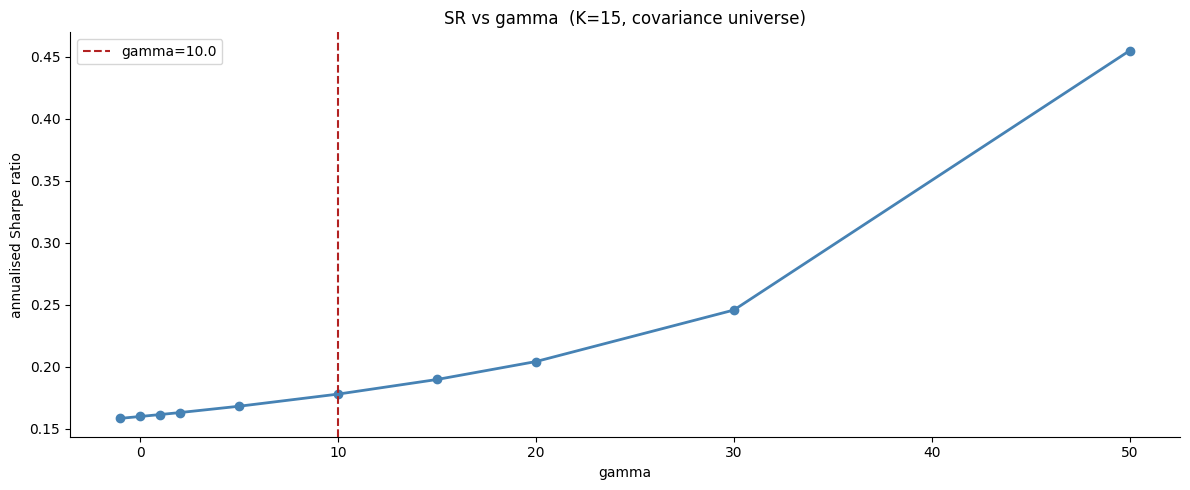

In [8]:
# -------------------- gamma sweep --------------------
# confirm gamma=10 is reasonable for this universe

sweep = sweep_gamma(cov_residuals.fillna(0).values, K=K)

fig, ax = plt.subplots()
ax.plot(sweep['gamma'], sweep['sr'], marker='o', color='steelblue', linewidth=2)
ax.axvline(GAMMA, color='firebrick', linestyle='--', label=f'gamma={GAMMA}')
ax.set_xlabel('gamma')
ax.set_ylabel('annualised Sharpe ratio')
ax.set_title(f'SR vs gamma  (K={K}, covariance universe)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/fig_sr_vs_gamma.png', dpi=150)
plt.show()

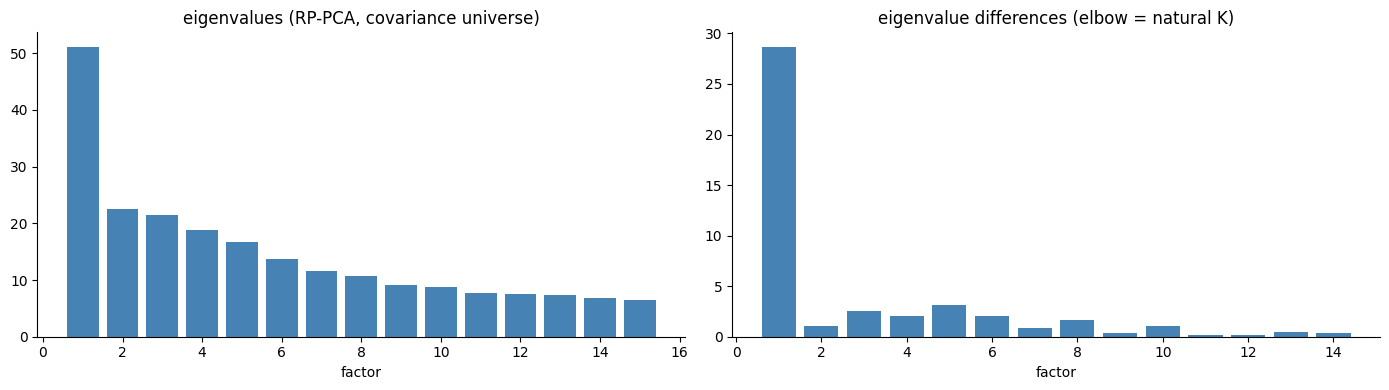

In [9]:
# -------------------- eigenvalue plot --------------------
# check how many factors are genuinely distinct (look for the elbow)

eigvals = rppca_result['eigvals']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, len(eigvals)+1), eigvals, color='steelblue')
axes[0].set_title('eigenvalues (RP-PCA, covariance universe)')
axes[0].set_xlabel('factor')

diffs = np.diff(eigvals)
axes[1].bar(range(1, len(diffs)+1), np.abs(diffs), color='steelblue')
axes[1].set_title('eigenvalue differences (elbow = natural K)')
axes[1].set_xlabel('factor')

plt.tight_layout()
plt.savefig('outputs/fig_eigenvalues.png', dpi=150)
plt.show()

## Step 3 — Label Theme Factors Using ETF Returns

In [10]:
# -------------------- 3. Theme DNA --------------------
# regress each ETF on the K factors to identify which factors = which themes
# R² tells us how well the factor space captures each theme
# purity tells us how much the ETFs within a theme agree

from src.theme_dna import label_theme_factors

dna_result = label_theme_factors(
    rppca_result, etf_residuals, themes_config,
    top_factors=TOP_FACTORS
)

print('\ntheme factor R² (how well factors explain each ETF):')
for etf, r2 in dna_result['etf_r2'].items():
    bar = '█' * int(r2 * 20)
    print(f'  {etf:20s}  R²={r2:.3f}  {bar}')

print('\ntheme purity (ETF agreement within theme):')
for theme, p in dna_result['purity'].items():
    bar = '█' * int(p * 20)
    print(f'  {theme:25s}  {p:.3f}  {bar}')


labeling theme factors using 43 ETFs:
  ETF                       R²  top factor weights
  ------------------------------------------------------------
  ARKF                   0.336  f10:-0.097, f3:-0.070, f9:+0.050
  BOTZ                   0.324  f4:-0.064, f5:+0.058, f13:+0.048
  CGW                    0.591  f4:-0.078, f1:-0.078, f12:+0.061
  CIBR                   0.311  f11:-0.118, f13:+0.081, f12:-0.067
  COPX                   0.377  f12:+0.105, f5:+0.075, f15:+0.061
  CUT                    0.400  f10:-0.085, f5:+0.081, f12:+0.070
  FINX                   0.436  f6:-0.088, f4:+0.082, f13:+0.055
  FIW                    0.629  f5:+0.087, f1:-0.071, f12:+0.069
  HACK                   0.247  f11:-0.102, f13:+0.076, f6:-0.058
  ICLN                   0.217  f4:-0.074, f12:+0.068, f15:+0.032
  IFRA                   0.660  f4:-0.088, f7:-0.075, f1:-0.071
  IGPT                   0.194  f11:-0.061, f10:+0.052, f13:+0.048
  IGV                    0.540  f6:-0.127, f7:-0.071, f11:-0

In [11]:
# -------------------- export signed factor loadings to CSV --------------------
K = rppca_result['factors'].shape[1]
cols = [f'factor_{k+1}' for k in range(K)]

etf_weights_df = pd.DataFrame.from_dict(dna_result['etf_weights'], orient='index', columns=cols)
etf_weights_df.index.name = 'ticker'
etf_weights_df.to_csv('outputs/etf_factor_weights.csv')
print(f"\nsaved: outputs/etf_factor_weights.csv  ({etf_weights_df.shape[0]} ETFs x {K} factors)")

theme_factors_df = pd.DataFrame.from_dict(dna_result['theme_factors'], orient='index', columns=cols)
theme_factors_df.index.name = 'theme'
theme_factors_df.to_csv('outputs/theme_factor_fingerprints.csv')
print(f"saved: outputs/theme_factor_fingerprints.csv  ({theme_factors_df.shape[0]} themes x {K} factors)")


saved: outputs/etf_factor_weights.csv  (43 ETFs x 15 factors)
saved: outputs/theme_factor_fingerprints.csv  (11 themes x 15 factors)


## Step 3.4 — Theme Coherence Diagnostic (Theme vs Narrative)

In [12]:
# -------------------- 3.4. Theme coherence: real cluster or taxonomic label? --------------------
# UPSTREAM garbage-in-garbage-out filter
# coherent theme (semis, defense) -> concentrated factor fingerprint -> clean baskets
# taxonomic theme (agribusiness) -> diffuse fingerprint -> contaminated baskets
# this flags WHICH themes the method can be trusted on, BEFORE building baskets

from src.theme_diagnostics import compute_coherence, print_coherence_report

baseline_config = etf_config[etf_config['type'].isin(['theme', 'sector', 'subsector'])]  # 17 labels, excludes factor ETFs

coherence = compute_coherence(
    rppca_result, etf_residuals, baseline_config,
    cov_residuals=cov_residuals, run_null=True, n_null=300, null_basket_size=TOP_N
)
print_coherence_report(coherence)

coherence_with_factors = compute_coherence(
    rppca_result, etf_residuals, etf_config,   # full 24 labels, appendix/robustness only
    cov_residuals=cov_residuals, run_null=True, n_null=300, null_basket_size=TOP_N
)

THEME DIAGNOSTIC  (coherence + distinctiveness)

coherence       = how concentrated the theme's factor fingerprint is
distinctiveness = how uniquely the theme OWNS its dominant factor
  COHERENT+DISTINCT = clean correct baskets
  COHERENT+SHARED   = clean-looking but contaminated (factor shared)
  DIFFUSE           = no single cluster -> taxonomic label

random real-stock null: p95 = 0.772

CALIBRATION ANCHORS (sectors/subsectors -- the coherence ceiling):
  SECTOR: US Energy           coh=0.665  dist=0.450  dom=factor_2 
  SUBSECTOR: US Software      coh=0.393  dist=0.317  dom=factor_6 
  SUBSECTOR: US Biotech       coh=0.300  dist=0.196  dom=factor_7 
  SECTOR: US Financials       coh=0.407  dist=0.194  dom=factor_4 
  SECTOR: US Technology       coh=0.344  dist=0.173  dom=factor_1 
  SUBSECTOR: US Banks         coh=0.323  dist=0.161  dom=factor_2 

THEMES (compare against the anchors above):
  Cybersecurity               coh=0.380  dist=0.335  dom=factor_11 (unique)      [OWNS FACTO

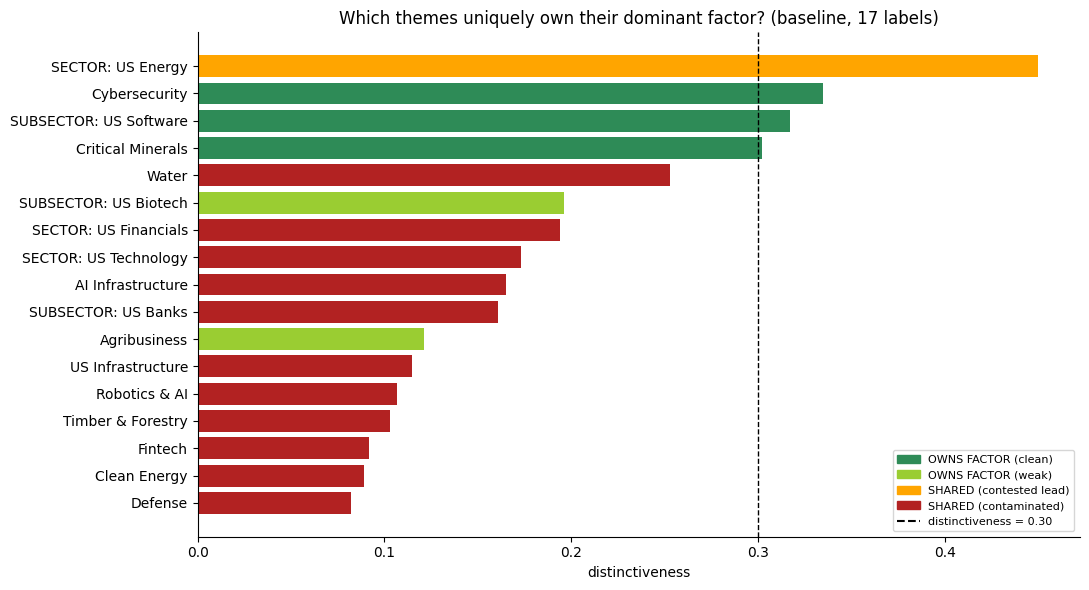

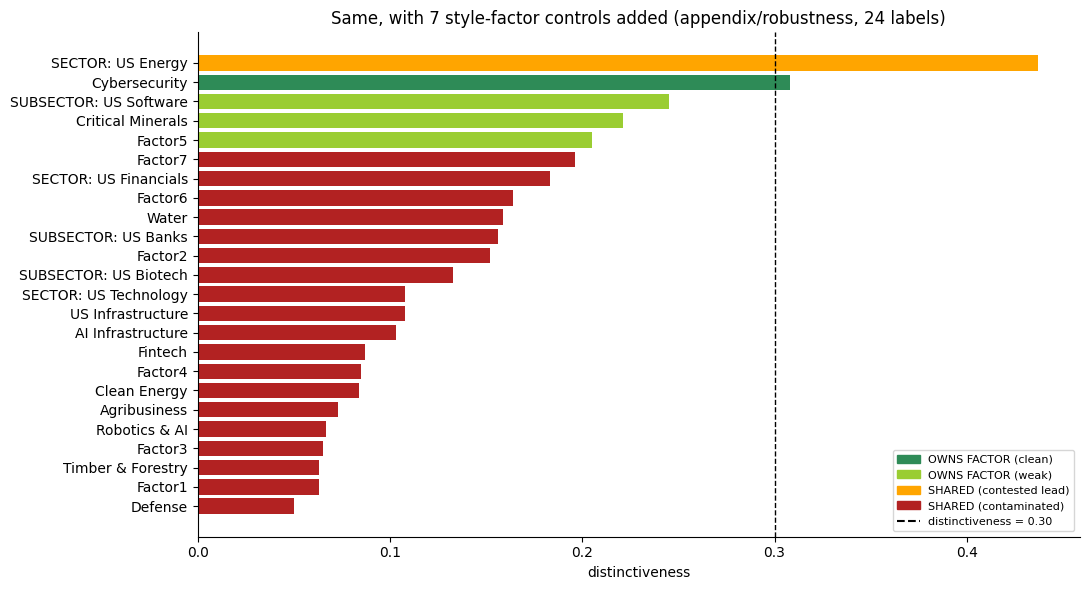

In [13]:
# -------------------- distinctiveness bar chart (replaces coherence-vs-null) --------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_distinctiveness(coh, title, filename):
    fig, ax = plt.subplots(figsize=(11, 6))
    coh = coh.sort_values('distinctiveness')
    color_map = {"OWNS FACTOR (clean)": "seagreen", "OWNS FACTOR (weak)": "yellowgreen",
                 "SHARED (contested lead)": "orange", "SHARED (contaminated)": "firebrick"}
    colors = [color_map.get(v, "gray") for v in coh['verdict']]
    ax.barh(range(len(coh)), coh['distinctiveness'].astype(float), color=colors)
    ax.set_yticks(range(len(coh))); ax.set_yticklabels(coh.index)
    ax.axvline(0.30, color='black', linestyle='--', linewidth=1)
    handles = [mpatches.Patch(color=c, label=v) for v, c in color_map.items()]
    handles.append(plt.Line2D([0], [0], color='black', linestyle='--', label='distinctiveness = 0.30'))
    ax.legend(handles=handles, loc='lower right', fontsize=8)
    ax.set_xlabel('distinctiveness'); ax.set_title(title)
    plt.tight_layout(); plt.savefig(filename, dpi=150); plt.show()

plot_distinctiveness(coherence, 'Which themes uniquely own their dominant factor? (baseline, 17 labels)',
                     'outputs/fig_theme_coherence_baseline.png')
plot_distinctiveness(coherence_with_factors, 'Same, with 7 style-factor controls added (appendix/robustness, 24 labels)',
                     'outputs/fig_theme_coherence_with_factors_appendix.png')

## Step 3.45 — K-Sweep: Is the Sector-vs-Theme Coherence Pattern Robust?

In [14]:
# -------------------- 3.45. coherence K-sweep --------------------
# at K=10, 17 labels pile onto 10 factors -> sharing is mechanically forced.
# does the sector-vs-theme coherence pattern survive when K is large enough
# for clusters to separate? if cross-sector themes (Water, AI Infra) stay more
# distinct than the GICS sectors they span even at high K, that's the
# regime-dependent-coherence result (not a K=10 artifact).

from src.theme_diagnostics import coherence_k_sweep, summarize_k_sweep

k_sweep = coherence_k_sweep(
    cov_residuals, etf_residuals, etf_config,
    k_values=[10, 15, 20, 25], gamma=0.0
)

k_pivot = summarize_k_sweep(k_sweep)
print('distinctiveness by K (sorted by mean across K):')
print(k_pivot.round(3).to_string())
k_pivot

RP-PCA fitted: K=10, gamma=0.0
  in-sample SR:      0.120
  top eigenvalues:   [51.1 22.5 21.4 18.8 16.8 13.7 11.6 10.7  9.1  8.7]
  K=10: fitted and scored 24 labels
RP-PCA fitted: K=15, gamma=0.0
  in-sample SR:      0.160
  top eigenvalues:   [51.1 22.5 21.4 18.8 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5]
  K=15: fitted and scored 24 labels
RP-PCA fitted: K=20, gamma=0.0
  in-sample SR:      0.187
  top eigenvalues:   [51.1 22.5 21.4 18.8 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5  6.4  6.2  6.   5.5  5.4]
  K=20: fitted and scored 24 labels
RP-PCA fitted: K=25, gamma=0.0
  in-sample SR:      0.212
  top eigenvalues:   [51.1 22.5 21.4 18.8 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5  6.4  6.2  6.   5.5  5.4  5.2  5.1  4.9  4.9  4.8]
  K=25: fitted and scored 24 labels
distinctiveness by K (sorted by mean across K):
K                            type     10     15     20     25  mean_dist
label                                                     

K,type,10,15,20,25,mean_dist
label,,,,,,
SECTOR: US Energy,sector,0.437,0.437,0.437,0.437,0.43700
SUBSECTOR: US Software,subsector,0.245,0.245,0.245,0.245,0.24500
Cybersecurity,theme,0.062,0.305,0.305,0.305,0.24425
Factor5,factor,0.205,0.205,0.205,0.205,0.20500
Factor7,factor,0.195,0.195,0.195,0.195,0.19500
SECTOR: US Financials,sector,0.182,0.182,0.182,0.182,0.18200
Critical Minerals,theme,0.053,0.220,0.220,0.220,0.17825
Factor6,factor,0.163,0.163,0.163,0.163,0.16300
Water,theme,0.159,0.159,0.159,0.159,0.15900


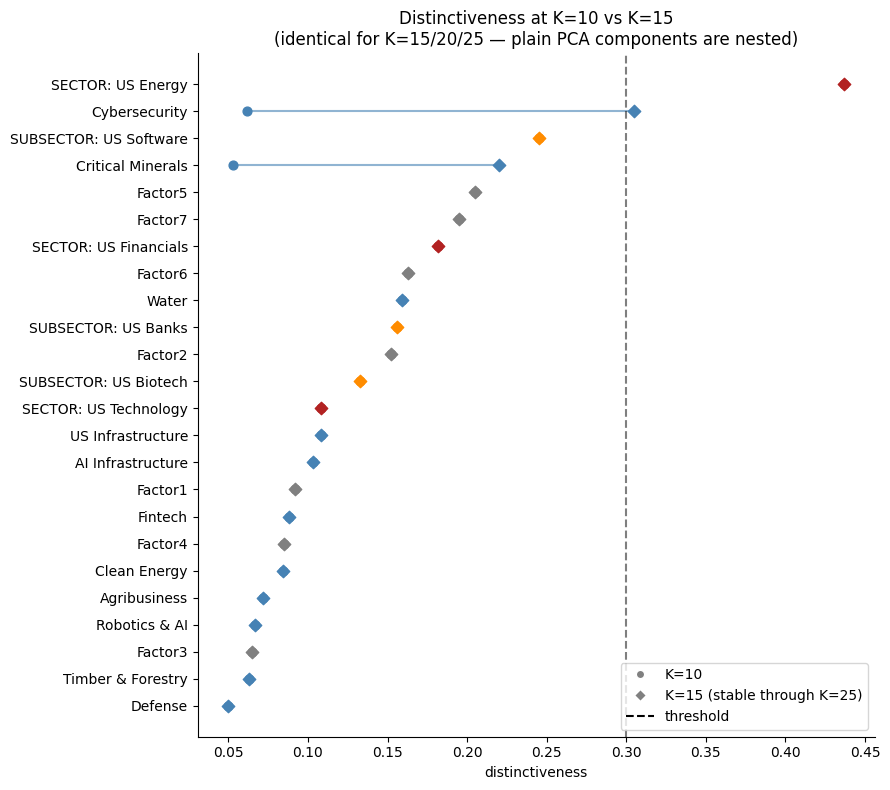

In [15]:
# -------------------- K=10 vs K=15 slope chart (replaces K-sweep spaghetti) --------------------
import matplotlib.pyplot as plt

piv = k_sweep[k_sweep['K'].isin([10, 15])].pivot(index='label', columns='K', values='distinctiveness')
piv = piv.join(k_sweep.drop_duplicates('label').set_index('label')['type'])
piv = piv.sort_values(15, ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
type_color = {'sector': 'firebrick', 'subsector': 'darkorange', 'theme': 'steelblue'}

for label, row in piv.iterrows():
    c = type_color.get(row['type'], 'gray')
    ax.plot([row[10], row[15]], [label, label], color=c, alpha=0.6, linewidth=1.5, zorder=1)
    ax.scatter(row[10], label, color=c, marker='o', s=40, zorder=2)
    ax.scatter(row[15], label, color=c, marker='D', s=40, zorder=2)

ax.axvline(0.30, color='black', linestyle='--', alpha=0.5, label='distinctiveness = 0.30')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', label='K=10'),
           plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='gray', label='K=15 (stable through K=25)')]
ax.legend(handles=handles + [plt.Line2D([0],[0], linestyle='--', color='black', label='threshold')],
          loc='lower right')
ax.set_xlabel('distinctiveness')
ax.set_title('Distinctiveness at K=10 vs K=15\n(identical for K=15/20/25 — plain PCA components are nested)')
plt.tight_layout()
plt.savefig('outputs/fig_coherence_ksweep.png', dpi=150)
plt.show()

In [16]:
# -------------------- 3.46. Sensitivity to label population (Appendix B) --------------------
# does a theme's clean/shared verdict depend on WHICH OTHER labels are in the run,
# not just on its own factor loading? cheap sibling to the K-sweep above.

from src.theme_diagnostics import compute_coherence

themes_only = etf_config[etf_config['type'] == 'theme']
control_names = etf_config[etf_config['type'].isin(['sector', 'subsector'])]['theme'].unique().tolist()

variants = {
    'baseline (17: themes + all controls)': baseline_config,
    'themes only (11, no controls)':        themes_only,
    'baseline + 7 factor ETFs (24)':        etf_config,
}
for ctrl in control_names:
    variants[f'baseline minus {ctrl}'] = baseline_config[baseline_config['theme'] != ctrl]

rows = []
for variant_name, cfg in variants.items():
    coh = compute_coherence(rppca_result, etf_residuals, cfg,
                             cov_residuals=cov_residuals, run_null=False)
    for theme in themes_only['theme'].unique():
        if theme in coh.index:
            rows.append({'variant': variant_name, 'theme': theme,
                          'distinctiveness': coh.loc[theme, 'distinctiveness'],
                          'verdict': coh.loc[theme, 'verdict']})

sensitivity = pd.DataFrame(rows)
pivot_dist = sensitivity.pivot(index='theme', columns='variant', values='distinctiveness')
pivot_verdict = sensitivity.pivot(index='theme', columns='variant', values='verdict')

print("Distinctiveness by label population:")
print(pivot_dist.round(3).to_string())

print("\nThemes whose verdict changes depending on label population:")
flipped = False
for theme in pivot_verdict.index:
    if pivot_verdict.loc[theme].nunique() > 1:
        flipped = True
        print(f"  {theme}: {dict(pivot_verdict.loc[theme])}")
if not flipped:
    print("  none -- all themes' verdicts are stable across every label population tested.")

pivot_dist.to_csv('outputs/data/sensitivity_label_population.csv')

Distinctiveness by label population:
variant            baseline (17: themes + all controls)  baseline + 7 factor ETFs (24)  baseline minus SECTOR: US Energy  baseline minus SECTOR: US Financials  baseline minus SECTOR: US Technology  baseline minus SUBSECTOR: US Banks  baseline minus SUBSECTOR: US Biotech  baseline minus SUBSECTOR: US Software  themes only (11, no controls)
theme                                                                                                                                                                                                                                                                                                                                               
AI Infrastructure                                 0.165                          0.103                             0.166                                 0.168                                 0.199                               0.166                                 0.168           

## Step 3.5 — What Does Each Factor Actually Represent?

In [17]:
# -------------------- 3.5. Factor interpretation diagnostic --------------------
# the key test of the regime hypothesis:
# - does PC1 light up only AI themes? (=> AI is the dominant axis)
# - do PC2, PC3... each map to a distinct theme? (=> secondary themes recoverable)
# - or are PC2+ diffuse across all themes? (=> secondary structure is noise)

from src.theme_dna import interpret_factors

factor_interp = interpret_factors(rppca_result, etf_residuals, etf_config)

# show the R² of each theme on each factor, rounded
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('R² of each theme on each individual factor:')
print((factor_interp.drop(columns=['dominant_factor','max_r2']) * 100).round(1))
print('\ndominant factor per theme:')
print(factor_interp[['dominant_factor','max_r2']].to_string())

R² of each theme on each individual factor:
                        factor_1  factor_2  factor_3  factor_4  factor_5  factor_6  factor_7  factor_8  factor_9  factor_10  factor_11  factor_12  factor_13  factor_14  factor_15
Robotics & AI               12.8       5.3       7.6      11.9       5.3       0.1       1.0       2.1       0.0        0.2        1.8        1.5        3.0        0.1        0.1
AI Infrastructure           19.6       1.3      16.0      14.1       0.1       0.1       0.1       1.4       1.5        5.3        6.1        0.3        2.6        0.2        0.1
Clean Energy                 0.2       0.5       1.7      13.9       0.0       0.1       0.9       0.3       0.5        0.3        0.3        1.3        0.3        0.0        2.5
Cybersecurity                0.2       0.9       0.0       1.3       0.2       5.5       2.2       0.1       1.3        0.1        9.9        2.4        4.7        0.1        0.1
Defense                      6.9       4.4       3.3       2.

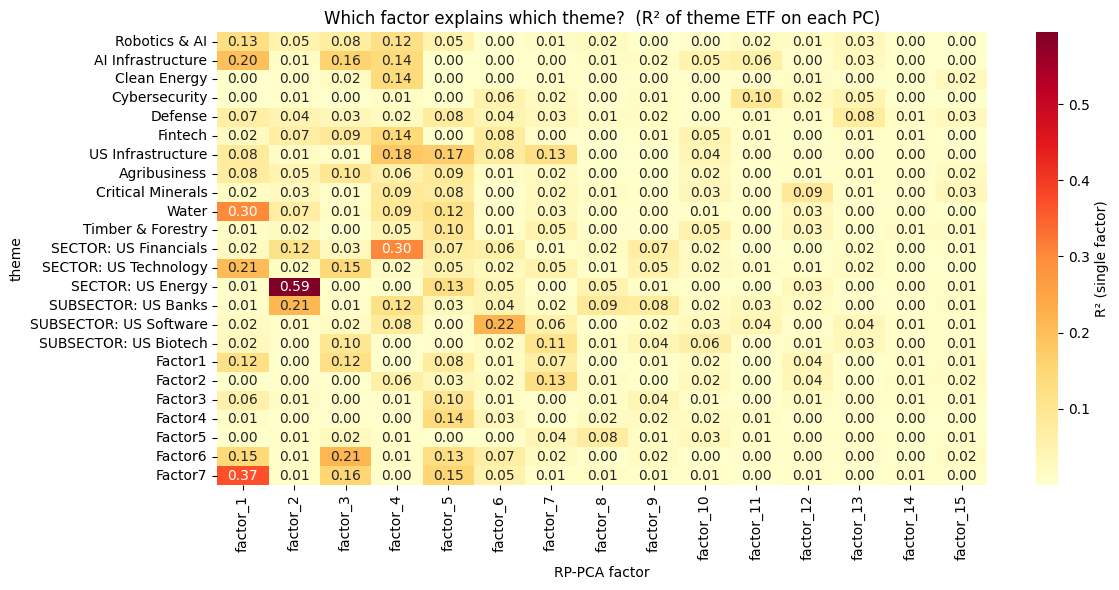

In [18]:
# -------------------- heatmap: theme x factor R² --------------------
# diagonal-ish structure = each theme has its own factor (good)
# one column dominating = single regime axis (the AI hypothesis)

import seaborn as sns
import matplotlib.pyplot as plt

heat = factor_interp.drop(columns=['dominant_factor','max_r2'])
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'R² (single factor)'})
ax.set_title('Which factor explains which theme?  (R² of theme ETF on each PC)')
ax.set_xlabel('RP-PCA factor')
ax.set_ylabel('theme')
plt.tight_layout()
plt.savefig('outputs/fig_factor_interpretation.png', dpi=150)
plt.show()

In [19]:
# -------------------- 3.6. Label factors by their top-loading stocks --------------------
# the heatmap tells us WHICH factor each theme loads on
# this tells us WHAT each factor actually contains
# if factor_2 (Defense's factor) is full of aerospace names, structure is real

from src.theme_dna import label_factors_by_stocks, print_factor_labels

factor_labels = label_factors_by_stocks(rppca_result, top_n=12)
print_factor_labels(factor_labels, top_n=10)


factor_1
  + tail: NVDA(+0.057), MU(+0.052), TSM(+0.051), COHR(+0.048), MRVL(+0.048), AVGO(+0.046), RMBS(+0.044), FORM(+0.040), GOOGL(+0.039), AMAT(+0.039)
  - tail: CMS(-0.113), WEC(-0.110), LNT(-0.110), DUK(-0.109), AWK(-0.107), AEP(-0.105), AEE(-0.105), DTE(-0.105), SO(-0.104), EVRG(-0.103)

factor_2
  + tail: EOG(+0.142), COP(+0.141), XOM(+0.138), TRGP(+0.137), DVN(+0.136), CVE(+0.135), FANG(+0.134), APA(+0.130), OXY(+0.128), CVX(+0.123)
  - tail: MAS(-0.093), FITB(-0.090), CFG(-0.090), PNC(-0.088), USB(-0.088), HBAN(-0.086), KEY(-0.086), SWK(-0.080), PNFP(-0.079), TFC(-0.079)

factor_3
  + tail: GILD(+0.104), JNJ(+0.099), GIS(+0.097), AMGN(+0.094), KR(+0.087), SJM(+0.086), BRK-B(+0.084), PFE(+0.083), CAG(+0.081), MCK(+0.079)
  - tail: SPG(-0.112), VTR(-0.093), NCLH(-0.090), CCL(-0.089), RCL(-0.089), UAL(-0.088), DAL(-0.086), RITM(-0.085), MGM(-0.085), IHG(-0.084)

factor_4
  + tail: V(+0.104), GPN(+0.099), MA(+0.091), FISV(+0.087), AXP(+0.086), FIS(+0.084), HBAN(+0.082), EXPE(+0.

## Step 3.7 — Does Higher Gamma Strengthen Theme Detection?

RP-PCA fitted: K=15, gamma=-1
  in-sample SR:      0.159
  top eigenvalues:   [51.1 22.5 21.4 18.8 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5]
  gamma=   -1: mean theme R²=0.1812, best=0.5941, worst=0.0766
RP-PCA fitted: K=15, gamma=0
  in-sample SR:      0.160
  top eigenvalues:   [51.1 22.5 21.4 18.8 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5]
  gamma=    0: mean theme R²=0.1812, best=0.5941, worst=0.0766
RP-PCA fitted: K=15, gamma=5
  in-sample SR:      0.168
  top eigenvalues:   [51.1 22.5 21.4 18.9 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5]
  gamma=    5: mean theme R²=0.1813, best=0.5941, worst=0.0766
RP-PCA fitted: K=15, gamma=10
  in-sample SR:      0.178
  top eigenvalues:   [51.1 22.5 21.4 18.9 16.8 13.7 11.6 10.7  9.1  8.7  7.7  7.5  7.3  6.9
  6.5]
  gamma=   10: mean theme R²=0.1814, best=0.5941, worst=0.0766
RP-PCA fitted: K=15, gamma=20
  in-sample SR:      0.204
  top eigenvalues:   [51.2 22.5 21.4 18.9 16.8 13.7 11.6 10.7  9.1  8

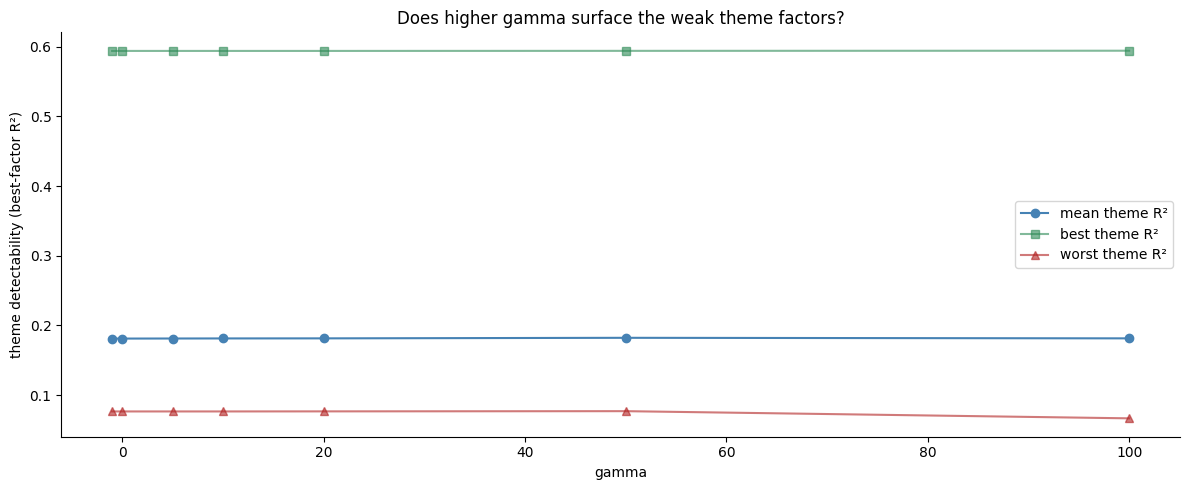

,gamma,mean_best_r2,max_best_r2,min_best_r2
0,-1,0.1812,0.5941,0.0766
1,0,0.1812,0.5941,0.0766
2,5,0.1813,0.5941,0.0766
3,10,0.1814,0.5941,0.0766
4,20,0.1815,0.5941,0.0767
5,50,0.1823,0.5942,0.0770
6,100,0.1815,0.5944,0.0667


In [20]:
# NOTE: on standardized residuals, gamma has little/no effect because
# residuals are mean-zero -- RP-PCA's gamma*mu*mu' penalty vanishes.
# this sweep confirms that empirically. on residuals we are effectively
# running plain PCA (correlation decomposition), which is the correct
# tool for theme DISCOVERY (co-movement structure, not high-Sharpe SDF).

# -------------------- 3.7. Gamma sweep on theme detectability --------------------
# themes are WEAK factors (max R² ~0.09) -- exactly what RP-PCA's gamma is for
# does raising gamma pull the weak theme factors up and make them more detectable?
# this is the RIGHT gamma diagnostic for residualized returns
# (the standard Sharpe-based sweep is near-zero and uninformative on residuals)

from src.theme_dna import sweep_gamma_theme_detection

gamma_sweep = sweep_gamma_theme_detection(
    cov_residuals, etf_residuals, etf_config,
    gammas=[-1, 0, 5, 10, 20, 50, 100], K=K
)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(gamma_sweep['gamma'], gamma_sweep['mean_best_r2'], marker='o', label='mean theme R²', color='steelblue')
ax.plot(gamma_sweep['gamma'], gamma_sweep['max_best_r2'], marker='s', label='best theme R²', color='seagreen', alpha=0.6)
ax.plot(gamma_sweep['gamma'], gamma_sweep['min_best_r2'], marker='^', label='worst theme R²', color='firebrick', alpha=0.6)
ax.set_xlabel('gamma')
ax.set_ylabel('theme detectability (best-factor R²)')
ax.set_title('Does higher gamma surface the weak theme factors?')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/fig_gamma_theme_detection.png', dpi=150)
plt.show()
gamma_sweep

## Step 4 — Project Target Universe + Score

In [21]:
# -------------------- 4. Project and score --------------------
# project each Russell proxy stock into the covariance factor space (OLS)
# score by cosine similarity to each theme fingerprint

from src.projection import project_universe, score_universe, save_projections

projections = project_universe(tgt_residuals, rppca_result)
scores      = score_universe(projections, dna_result['theme_factors'])
save_projections(projections, scores)

# score distribution per theme
scores.describe()


projecting 811 target stocks into factor space
  common dates: 438 weeks
  projections: 811 stocks x 15 factors

scores: 811 stocks x 11 themes
  range: [-0.766, 0.847]
saved: C:\Users\aamin\Thematic Engine\src\..\outputs\data\projections.csv
saved: C:\Users\aamin\Thematic Engine\src\..\outputs\data\scores.csv


,Robotics & AI,AI Infrastructure,Clean Energy,Cybersecurity,Defense,Fintech,US Infrastructure,Agribusiness,Critical Minerals,Water,Timber & Forestry
count,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000
mean,0.010759,0.024054,0.043283,0.060431,0.076896,0.099790,-0.078156,-0.009107,0.095124,0.031423,0.049692
std,0.219905,0.215366,0.253962,0.280016,0.254081,0.227256,0.203442,0.245137,0.266359,0.170984,0.252700
min,-0.566085,-0.602979,-0.644541,-0.766424,-0.712946,-0.622788,-0.691939,-0.753507,-0.563062,-0.515948,-0.616725
25%,-0.142046,-0.123592,-0.150009,-0.126157,-0.104308,-0.047245,-0.215229,-0.178965,-0.085557,-0.089933,-0.122340
50%,0.001071,0.025355,0.058699,0.082930,0.095928,0.098795,-0.088958,-0.008563,0.105000,0.037000,0.046290
75%,0.157958,0.168006,0.227331,0.248727,0.267503,0.252568,0.057908,0.161041,0.274891,0.153831,0.230986
max,0.687012,0.649700,0.678817,0.847173,0.679019,0.796272,0.591680,0.655154,0.768442,0.511719,0.694713


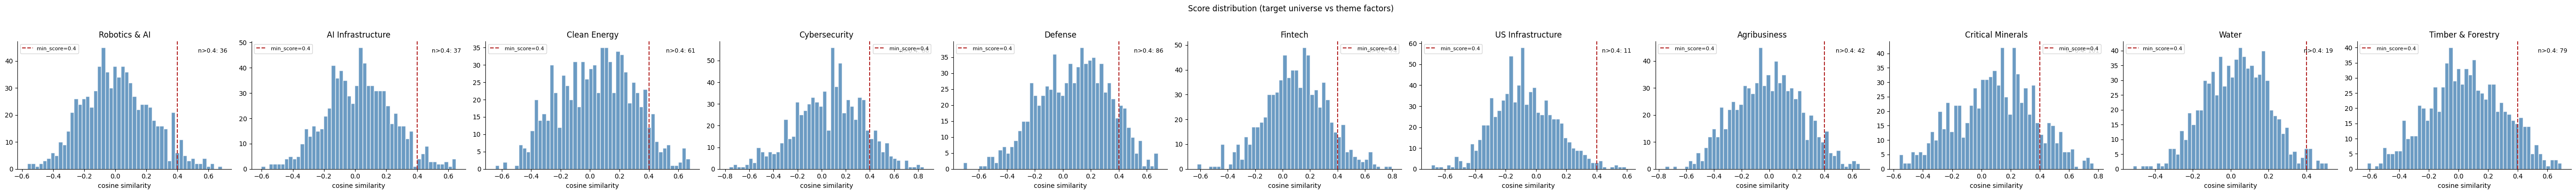

In [22]:
# -------------------- score distribution plot --------------------
# a healthy distribution is roughly normal, centered near 0
# the right tail (high scorers) are our candidates

fig, axes = plt.subplots(1, len(scores.columns), figsize=(5*len(scores.columns), 4))
if len(scores.columns) == 1:
    axes = [axes]

for ax, theme in zip(axes, scores.columns):
    s = scores[theme].dropna()
    ax.hist(s, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(MIN_SCORE, color='firebrick', linestyle='--',
               label=f'min_score={MIN_SCORE}')
    ax.set_title(theme)
    ax.set_xlabel('cosine similarity')
    ax.legend(fontsize=8)
    n_above = (s >= MIN_SCORE).sum()
    ax.text(0.98, 0.95, f'n>{MIN_SCORE}: {n_above}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle('Score distribution (target universe vs theme factors)', y=1.02)
plt.tight_layout()
plt.savefig('outputs/fig_score_distribution.png', dpi=150)
plt.show()

## Step 5 — Rank Candidates

In [23]:
# -------------------- 5. Rank candidates --------------------

from src.scoring import rank_candidates, save_outputs

ranked = rank_candidates(scores, top_n=TOP_N, min_score=MIN_SCORE)
save_outputs(ranked)

for theme in ranked['theme'].unique():
    print(f'\n--- {theme} (top 10) ---')
    print(ranked[ranked['theme'] == theme].head(10).to_string(index=False))


ranked candidates summary:
theme
AI Infrastructure    30
Agribusiness         30
Clean Energy         30
Critical Minerals    30
Cybersecurity        30
Defense              30
Fintech              30
Robotics & AI        30
Timber & Forestry    30
US Infrastructure    11
Water                19
saved: C:\Users\aamin\Thematic Engine\src\..\outputs\ranked_candidates.csv

--- Robotics & AI (top 10) ---
        theme  rank ticker  score
Robotics & AI     1    OEC 0.6870
Robotics & AI     2    MSC 0.6333
Robotics & AI     3   CMCO 0.6151
Robotics & AI     4   NVEC 0.5933
Robotics & AI     5   SILC 0.5843
Robotics & AI     6   ELDN 0.5763
Robotics & AI     7     MX 0.5745
Robotics & AI     8   CVGI 0.5712
Robotics & AI     9   IIIN 0.5576
Robotics & AI    10     DQ 0.5447

--- AI Infrastructure (top 10) ---
            theme  rank ticker  score
AI Infrastructure     1   HFBL 0.6497
AI Infrastructure     2     MX 0.6454
AI Infrastructure     3   QUIK 0.6285
AI Infrastructure     4   SLGL 0.

## Step 6 — OOS Validation Against ETF

In [24]:
# -------------------- 6. OOS validation --------------------
# do our top candidates actually co-move with the theme ETF?
# this is the key validation -- no constituent data needed
# high ETF correlation = RP-PCA found genuine thematic exposure

from src.projection import validate_against_etf

validation = validate_against_etf(
    scores, tgt_returns, etf_returns, themes_config,
    top_n=TOP_N, min_score=MIN_SCORE
)
missing = set(scores.columns) - set(validation['theme'])
if missing:
    print(f"WARNING: {len(missing)} theme(s) dropped from validation, check candidates/ETF coverage: {missing}")
validation


ranked candidates summary:
theme
AI Infrastructure    30
Agribusiness         30
Clean Energy         30
Critical Minerals    30
Cybersecurity        30
Defense              30
Fintech              30
Robotics & AI        30
Timber & Forestry    30
US Infrastructure    11
Water                19

OOS validation (correlation + beta decomposition):
            theme  n_candidates  etf_correlation  beta_to_etf  alpha_ann  tracking_error  tracking_diff  cum_ret_basket  cum_ret_etf
    Robotics & AI            30            0.805        0.873     -0.106           0.166         -0.117          -0.464        0.533
AI Infrastructure            30            0.765        0.828     -0.253           0.193         -0.294          -0.584        4.409
     Clean Energy            30            0.803        0.845     -0.340           0.223         -0.354          -0.940        0.318
    Cybersecurity            30            0.711        0.791     -0.196           0.198         -0.229          -0.60

,theme,n_candidates,etf_correlation,beta_to_etf,alpha_ann,tracking_error,tracking_diff,cum_ret_basket,cum_ret_etf,candidates
0,Robotics & AI,30,0.805,0.873,-0.106,0.166,-0.117,-0.464,0.533,"[OEC, MSC, CMCO, NVEC, SILC, ELDN, MX, CVGI, I..."
1,AI Infrastructure,30,0.765,0.828,-0.253,0.193,-0.294,-0.584,4.409,"[HFBL, MX, QUIK, SLGL, CMTL, NVEC, VREX, ARL, ..."
2,Clean Energy,30,0.803,0.845,-0.340,0.223,-0.354,-0.940,0.318,"[BLNK, CSIQ, HDSN, MRAM, CVV, ASPN, CODA, ASYS..."
3,Cybersecurity,30,0.711,0.791,-0.196,0.198,-0.229,-0.609,1.958,"[ELTK, III, BOC, EGAN, MVIS, HFBL, RPD, MNSB, ..."
4,Defense,30,0.791,0.816,-0.125,0.167,-0.150,-0.350,1.380,"[RDCM, AEYE, MITK, TATT, MRDN, ISSC, EBF, ELDN..."
5,Fintech,30,0.825,0.849,-0.183,0.184,-0.191,-0.805,0.033,"[DOMO, ANGI, RPAY, PERI, PRAA, IIIV, FLL, PAYS..."
6,US Infrastructure,11,0.780,0.967,-0.109,0.181,-0.113,-0.203,1.368,"[NVEC, APOG, MTRX, CWCO, ESOA, DCTH, ERII, ALO..."
7,Agribusiness,30,0.677,1.199,-0.262,0.222,-0.252,-0.873,0.412,"[ULH, PALI, FF, SXC, AREC, MGPI, GSM, UXIN, TW..."
8,Critical Minerals,30,0.773,0.789,-0.206,0.209,-0.231,-0.748,0.838,"[AEC, NGEN, LGO, VHI, SCZM, TWIN, EU, HYFT, AS..."
9,Water,19,0.737,1.025,-0.099,0.186,-0.096,-0.296,0.886,"[MHNC, CLPT, OEC, ASA, QTRX, FPH, PMN, CMCO, R..."


Fingerprint cosine similarity (model-based, full K-length vector):
                   Robotics & AI  AI Infrastructure  Clean Energy  Cybersecurity  Defense  Fintech  US Infrastructure  Agribusiness  Critical Minerals  Water  Timber & Forestry
Robotics & AI               1.00               0.60          0.57           0.21     0.57    -0.28               0.60          0.33               0.27   0.31               0.30
AI Infrastructure           0.60               1.00          0.49           0.43     0.12    -0.27               0.32         -0.13               0.02   0.13              -0.26
Clean Energy                0.57               0.49          1.00          -0.08     0.10    -0.44               0.43          0.29               0.66   0.32               0.18
Cybersecurity               0.21               0.43         -0.08           1.00     0.40     0.20               0.00          0.07              -0.19  -0.09              -0.12
Defense                     0.57               0

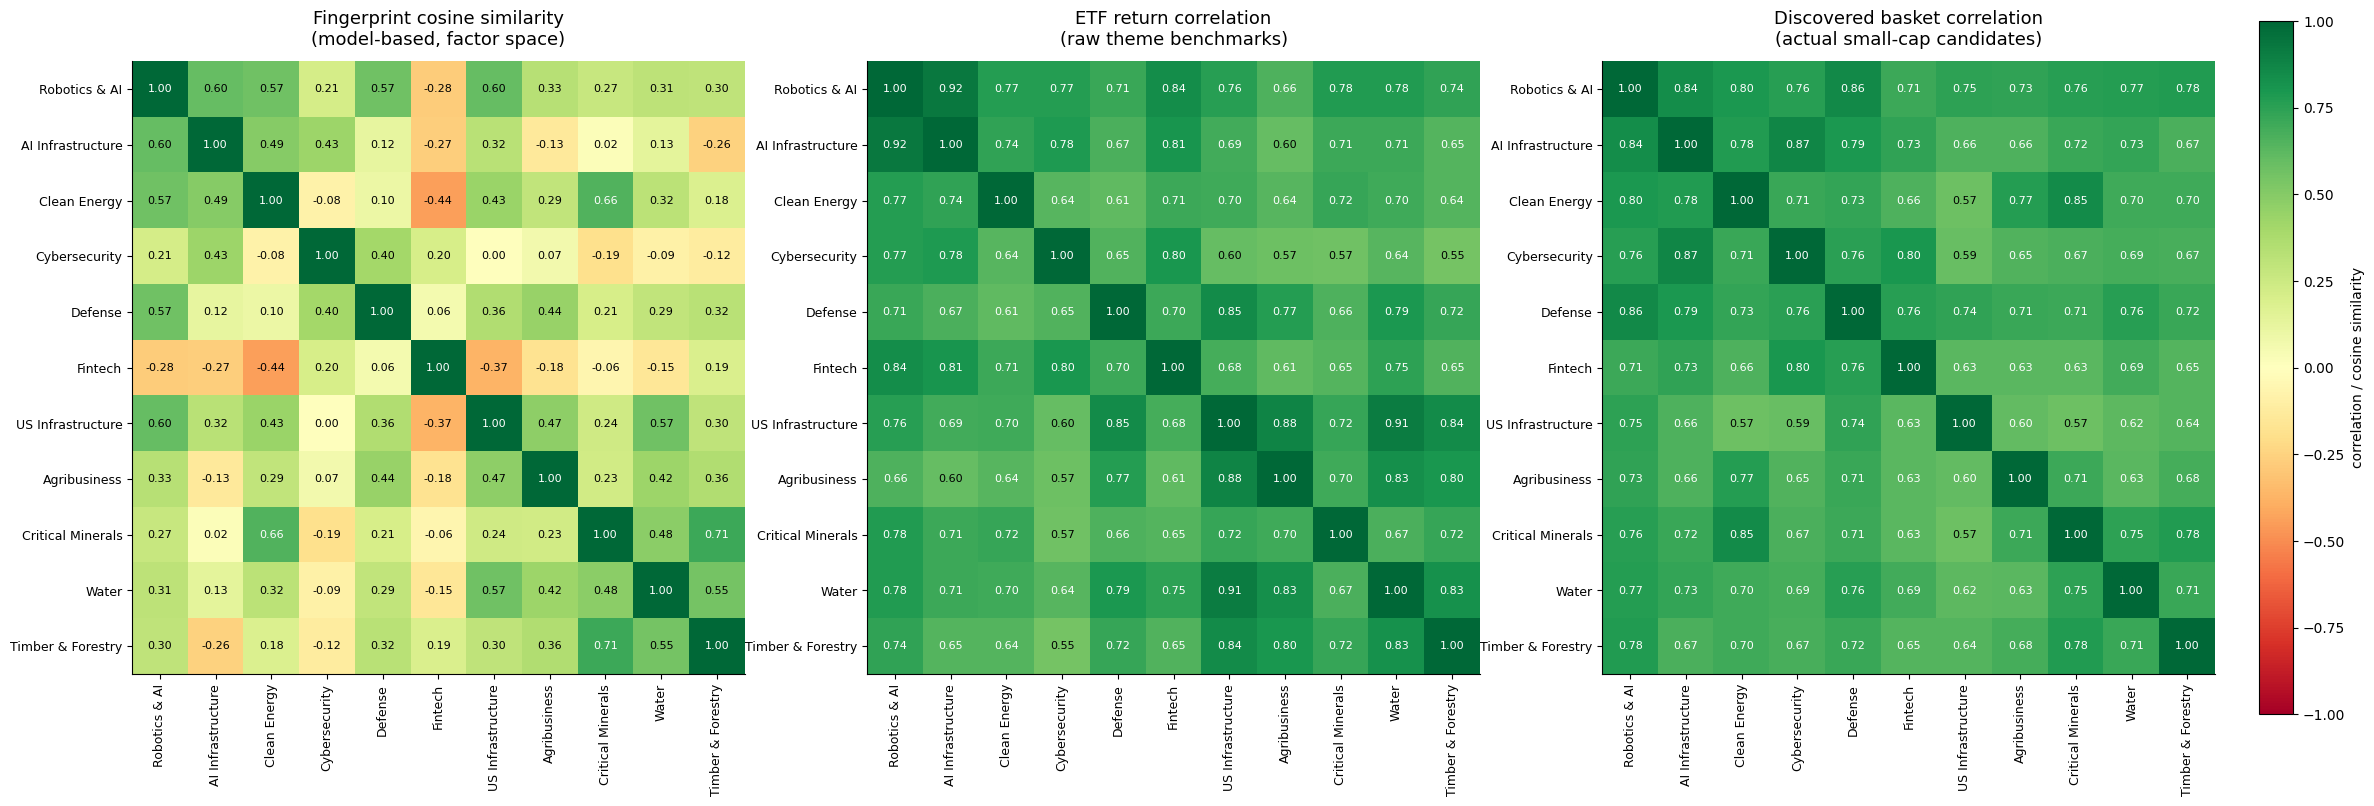

In [25]:
# -------------------- 3.47. Theme redundancy check: is AI Infra == Robotics & AI? --------------------
# cosine similarity of full fingerprints (model-based) + empirical correlation matrices
# (ETF-level and discovered-basket-level) to distinguish "same theme, mislabeled" from
# genuine crowding/regime overlap.

import numpy as np
import pandas as pd

theme_names = list(dna_result['theme_factors'].keys())
fp_matrix = np.array([dna_result['theme_factors'][t] for t in theme_names])

# cosine similarity of full K-dimensional fingerprints
norms = np.linalg.norm(fp_matrix, axis=1, keepdims=True)
cos_sim = (fp_matrix @ fp_matrix.T) / (norms @ norms.T)
cos_sim_df = pd.DataFrame(cos_sim, index=theme_names, columns=theme_names)

print("Fingerprint cosine similarity (model-based, full K-length vector):")
print(cos_sim_df.round(2).to_string())

# empirical correlation: theme-level ETF returns (mean of each theme's ETFs)
etf_theme_ret = pd.DataFrame({
    t: etf_returns[[e for e in themes_config[themes_config['theme'] == t]['ticker'] if e in etf_returns.columns]].mean(axis=1)
    for t in theme_names
})
etf_corr = etf_theme_ret.corr()
print("\nEmpirical correlation: theme ETF returns (raw, not residualized):")
print(etf_corr.round(2).to_string())

# empirical correlation: discovered candidate BASKETS (the actual tradeable objects)
assert 'validation' in dir(), "run the '6. OOS validation' cell first -- 'validation' is not defined yet"
basket_ret = pd.DataFrame({
    row['theme']: tgt_returns[row['candidates']].mean(axis=1)
    for _, row in validation.iterrows()
})
basket_corr = basket_ret.corr()
print("\nEmpirical correlation: discovered candidate baskets (small-cap, tradeable):")
print(basket_corr.round(2).to_string())

# heatmaps
# -------------------- larger, annotated heatmaps --------------------
def plot_annotated_heatmap(ax, data, title):
    im = ax.imshow(data.values, vmin=-1, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.columns, rotation=90, fontsize=9)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.set_title(title, fontsize=13, pad=12)
    # annotate each cell, flipping text color for readability on dark cells
    for i in range(len(data)):
        for j in range(len(data.columns)):
            val = data.values[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=8, color=color)
    return im

fig, axes = plt.subplots(1, 3, figsize=(28, 9))
panels = [
    (cos_sim_df, 'Fingerprint cosine similarity\n(model-based, factor space)'),
    (etf_corr,   'ETF return correlation\n(raw theme benchmarks)'),
    (basket_corr,'Discovered basket correlation\n(actual small-cap candidates)'),
]
for ax, (data, title) in zip(axes, panels):
    im = plot_annotated_heatmap(ax, data, title)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='correlation / cosine similarity')
plt.savefig('outputs/fig_theme_redundancy_check.png', dpi=150, bbox_inches='tight')
plt.show()
plt.show()

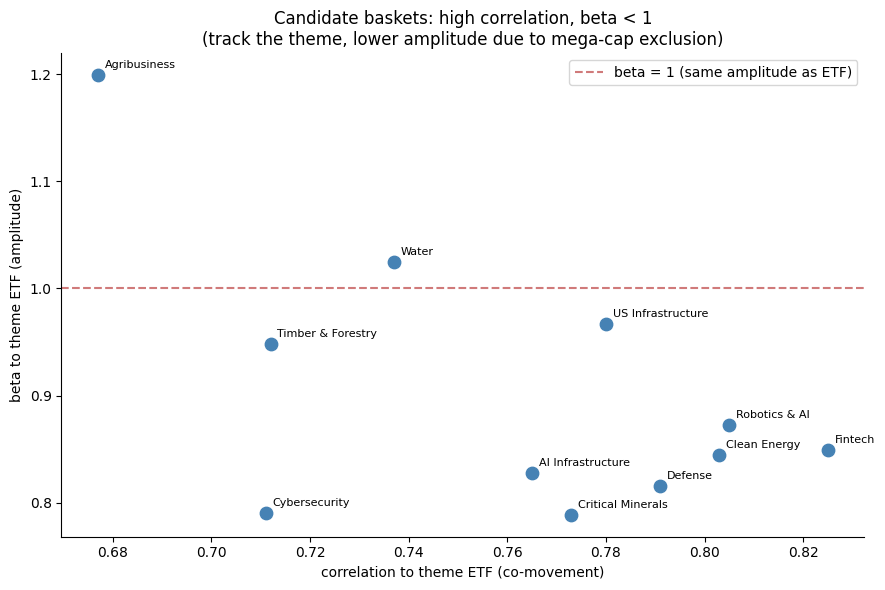

mean correlation across themes: 0.762
mean beta across themes:        0.903
themes with beta < 1: 9/11


In [26]:
# -------------------- correlation vs beta scatter --------------------
# the key picture: themes cluster at HIGH correlation but beta < 1
# = baskets track the theme direction but at lower amplitude
# this explains the visual gap between candidate (blue) and ETF (red)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(validation['etf_correlation'], validation['beta_to_etf'],
           s=80, color='steelblue', zorder=3)
for _, r in validation.iterrows():
    ax.annotate(r['theme'], (r['etf_correlation'], r['beta_to_etf']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.axhline(1.0, color='firebrick', linestyle='--', alpha=0.6,
           label='beta = 1 (same amplitude as ETF)')
ax.set_xlabel('correlation to theme ETF (co-movement)')
ax.set_ylabel('beta to theme ETF (amplitude)')
ax.set_title('Candidate baskets: high correlation, beta < 1\n'
             '(track the theme, lower amplitude due to mega-cap exclusion)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/fig_corr_vs_beta.png', dpi=150)
plt.show()

# summary: mean beta across themes
print(f"mean correlation across themes: {validation['etf_correlation'].mean():.3f}")
print(f"mean beta across themes:        {validation['beta_to_etf'].mean():.3f}")
print(f"themes with beta < 1: {(validation['beta_to_etf'] < 1).sum()}/{len(validation)}")

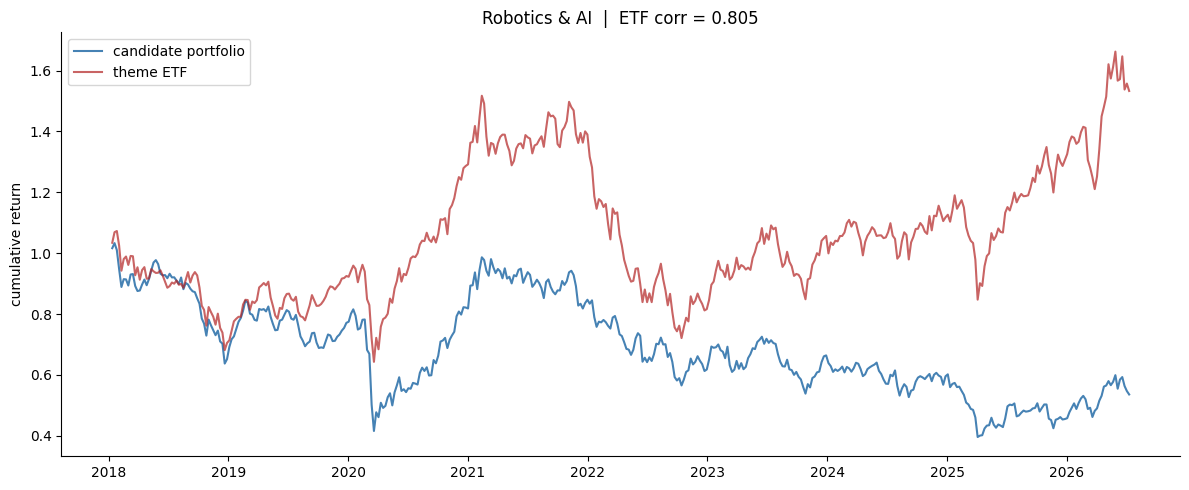

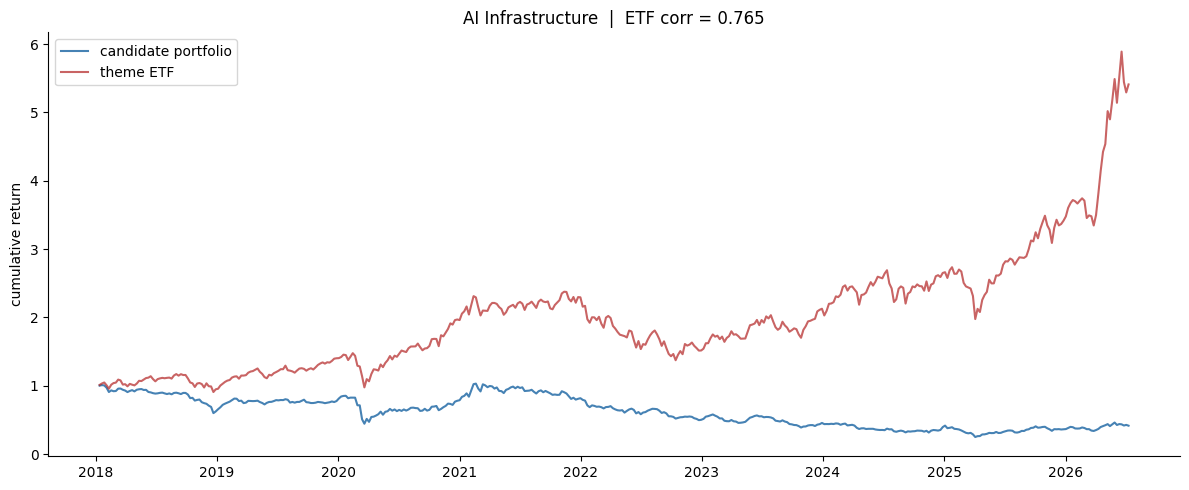

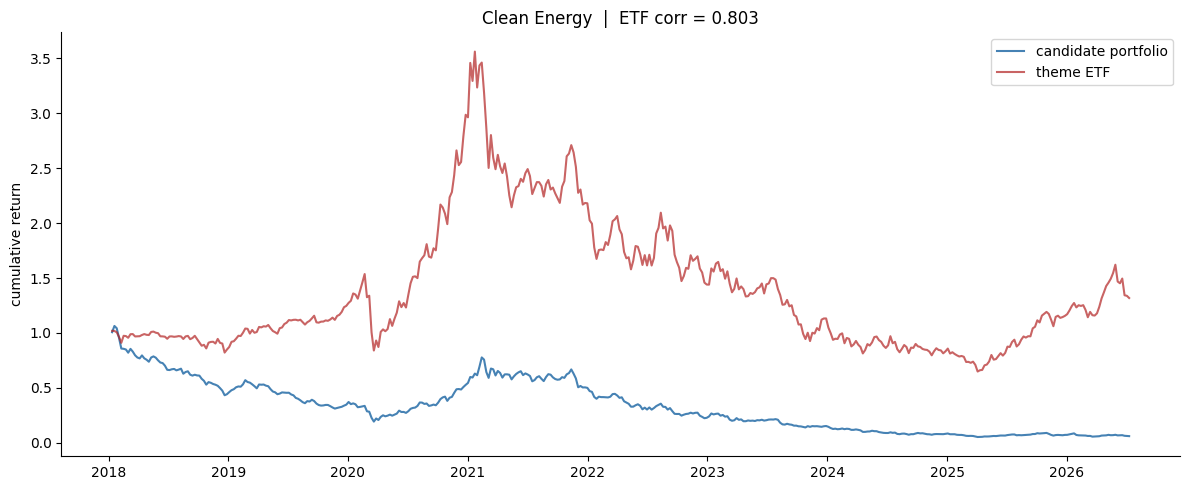

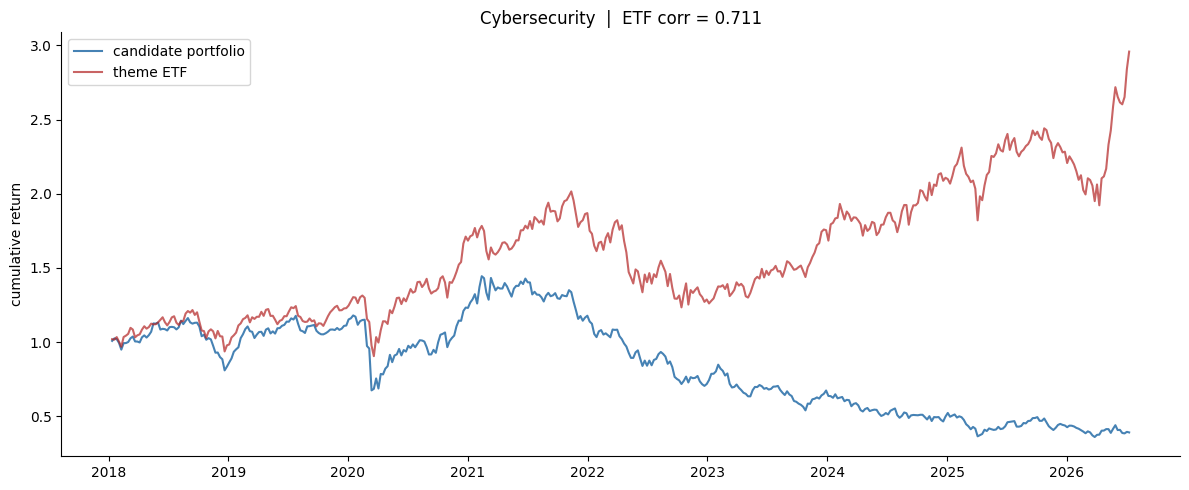

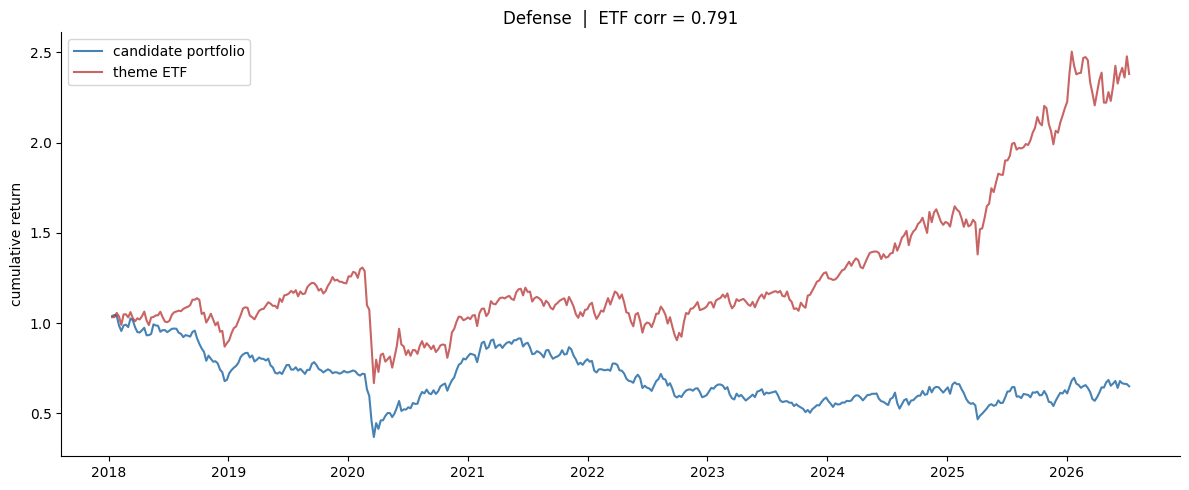

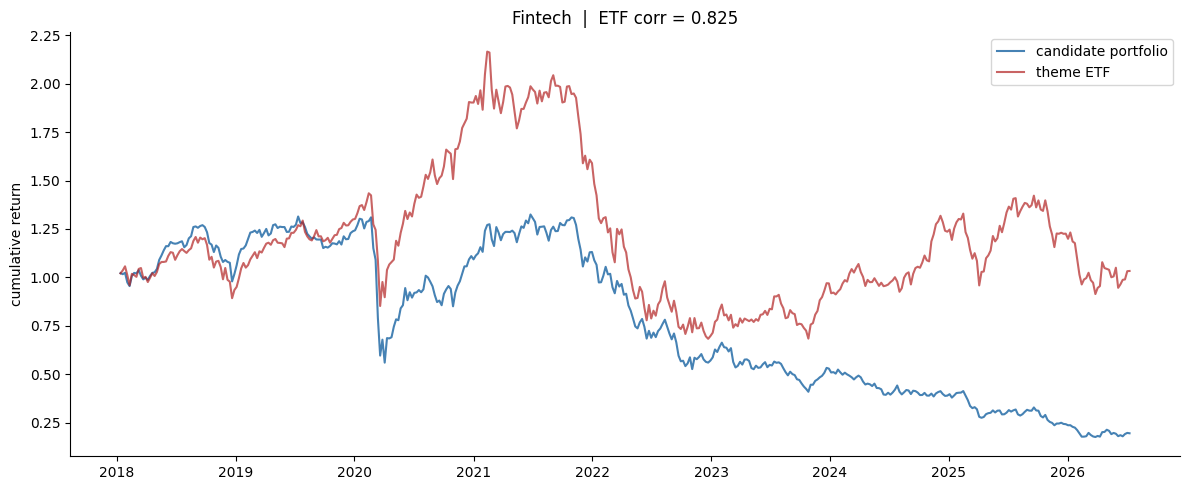

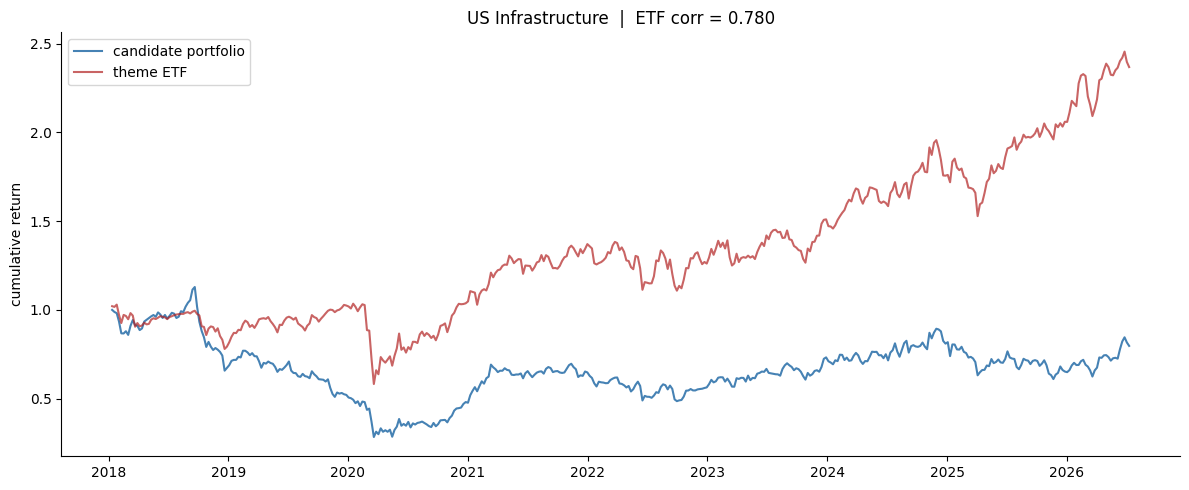

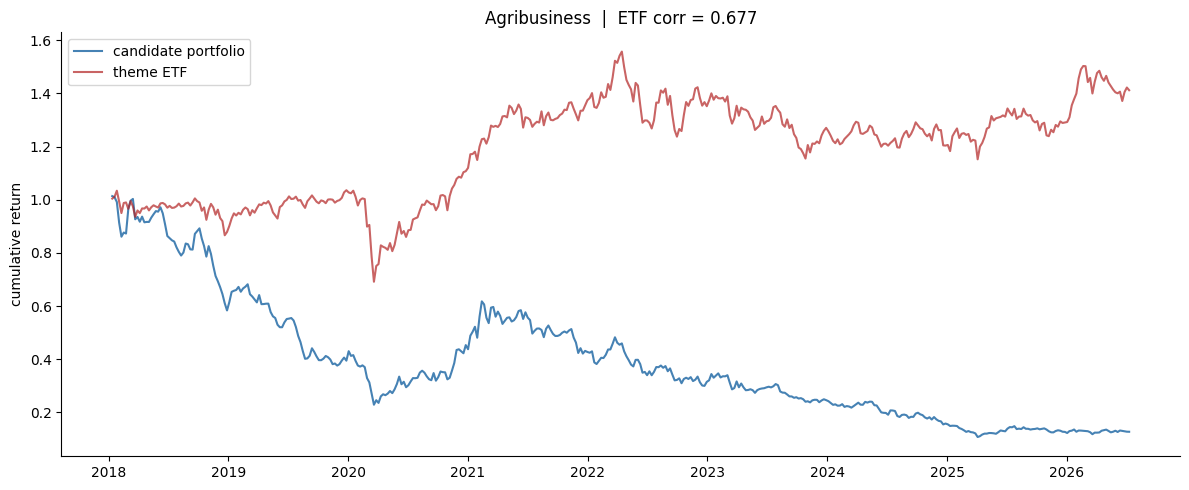

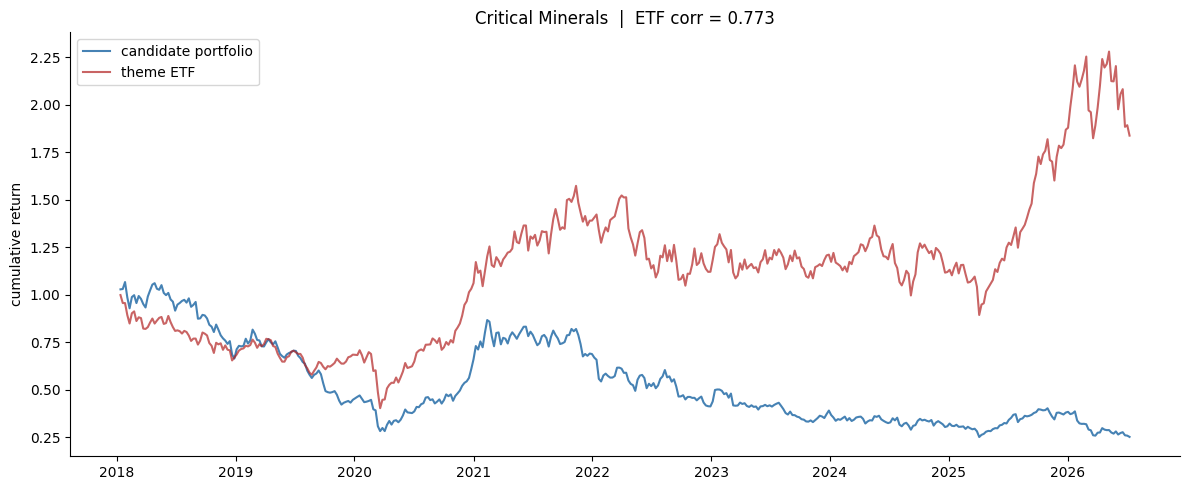

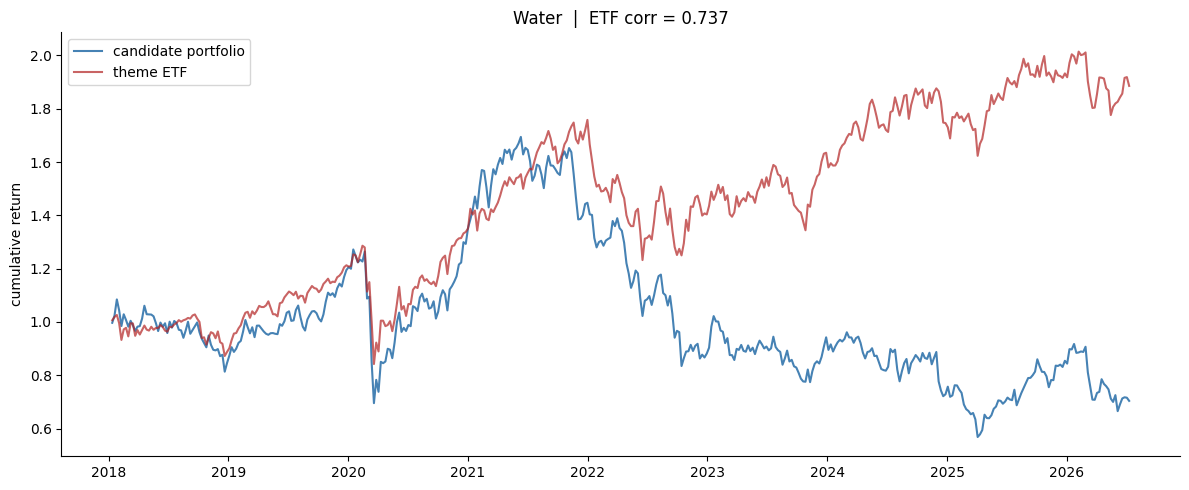

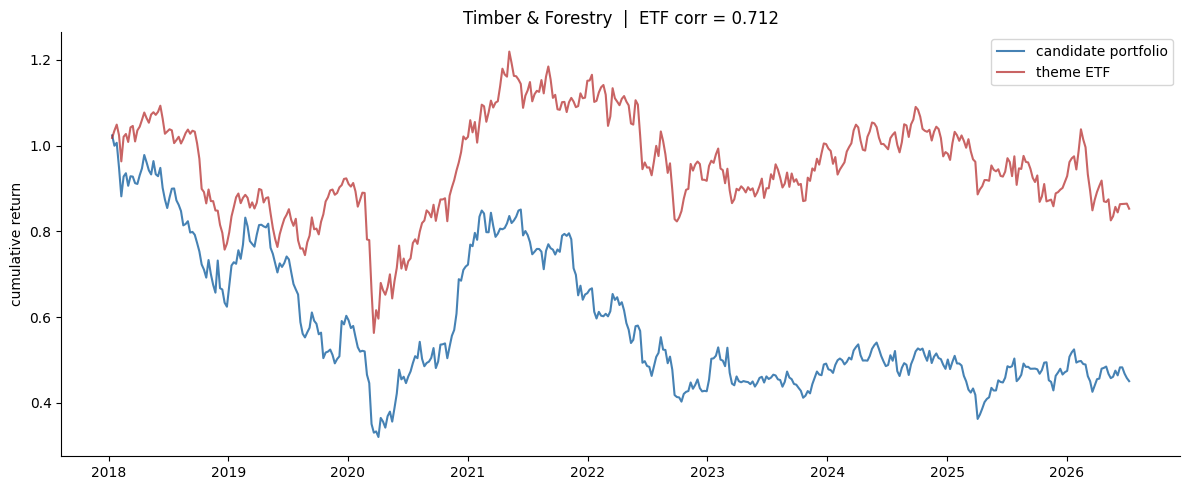

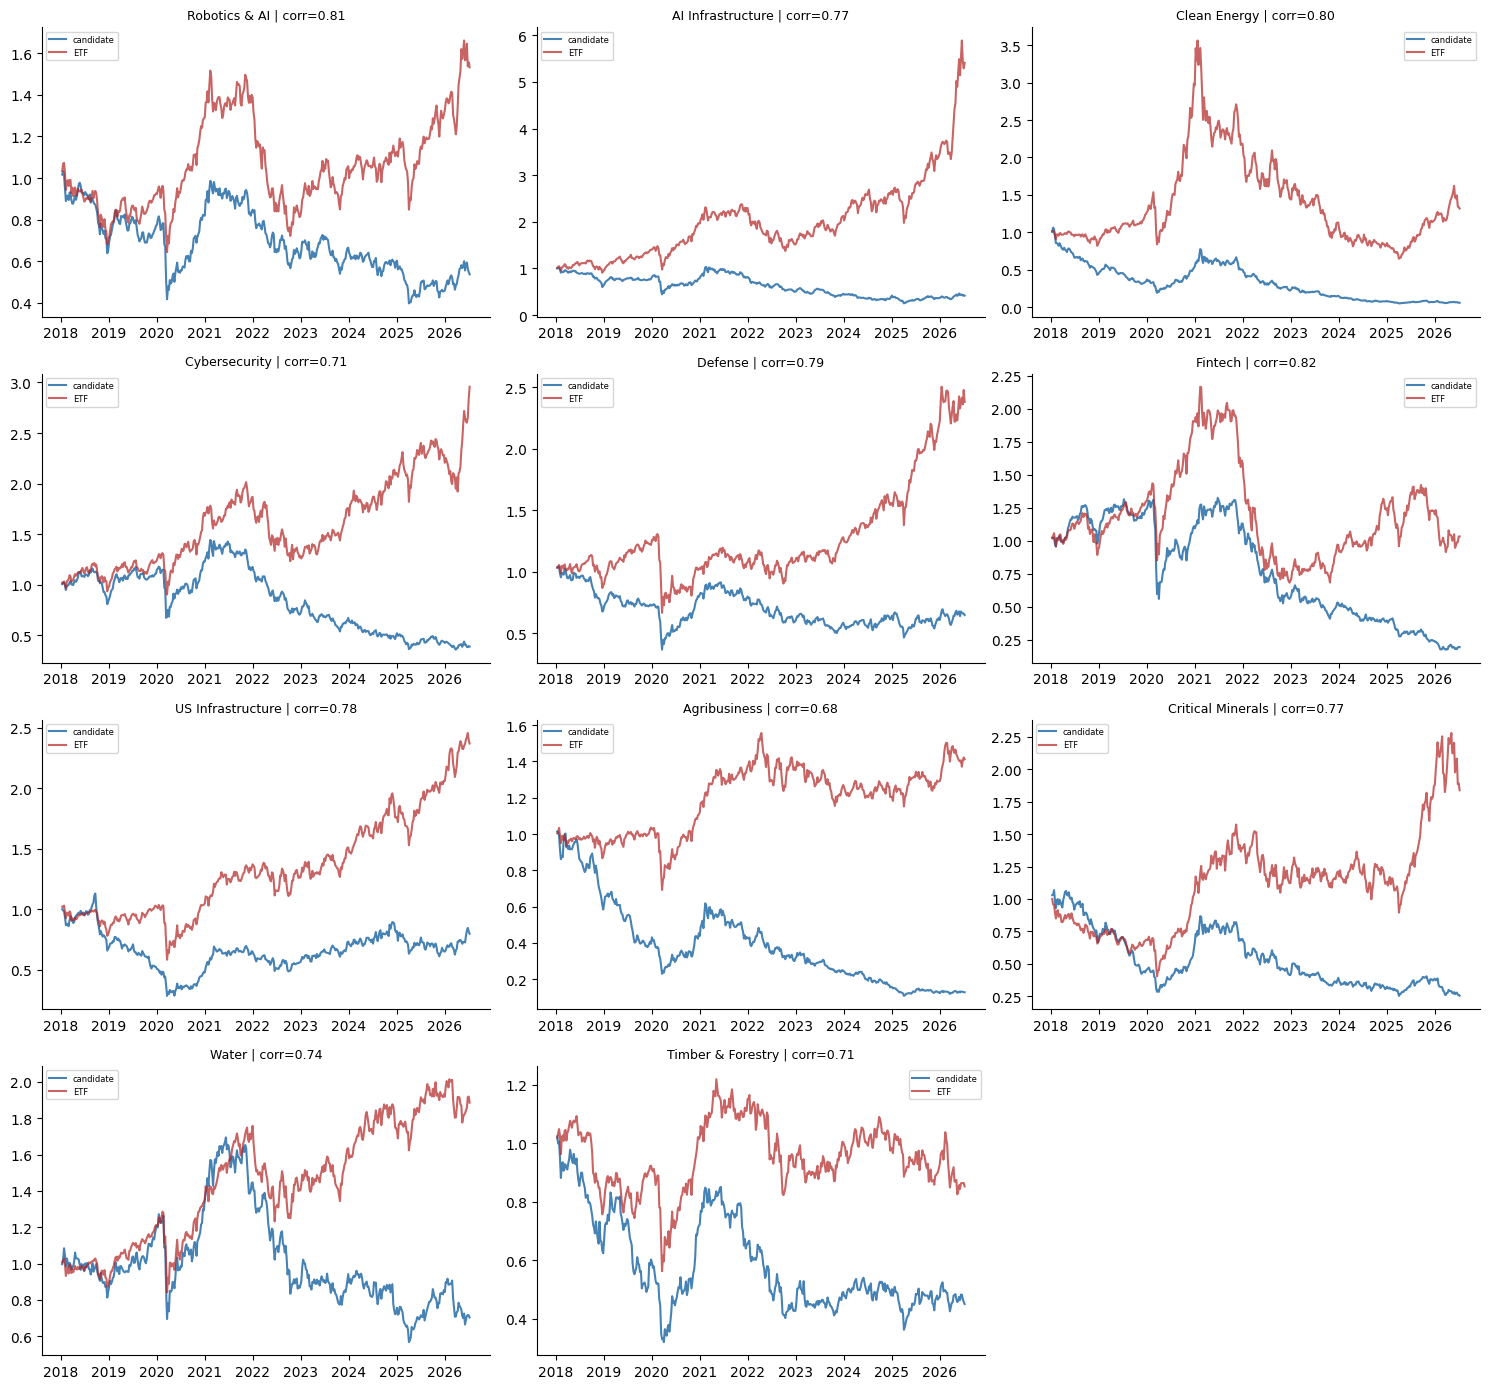

In [27]:
# -------------------- correlation plot --------------------
# for each theme: plot candidate portfolio return vs ETF return

for _, row in validation.iterrows():
    theme      = row['theme']
    candidates = row['candidates']
    theme_etfs = themes_config[themes_config['theme'] == theme]['ticker'].tolist()
    etf_avail  = [e for e in theme_etfs if e in etf_returns.columns]

    port_ret = tgt_returns[candidates].mean(axis=1)
    etf_ret  = etf_returns[etf_avail].mean(axis=1)
    common   = port_ret.index.intersection(etf_ret.index)

    # cumulative returns
    cum_port = (1 + port_ret.loc[common]).cumprod()
    cum_etf  = (1 + etf_ret.loc[common]).cumprod()

    fig, ax = plt.subplots()
    ax.plot(cum_port.index, cum_port.values, label='candidate portfolio', color='steelblue')
    ax.plot(cum_etf.index, cum_etf.values,   label='theme ETF',          color='firebrick', alpha=0.7)
    ax.set_title(f'{theme}  |  ETF corr = {row["etf_correlation"]:.3f}')
    ax.set_ylabel('cumulative return')
    ax.legend()
    plt.tight_layout()
    safe_name = theme.replace(' ', '_').replace('&', 'and')
    plt.savefig(f'outputs/fig_validation_{safe_name}.png', dpi=150)
    plt.show()

# -------------------- grid version of validation plots (comment out if cramped) --------------------
import math
n = len(validation)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = axes.flatten()
for ax, (_, row) in zip(axes, validation.iterrows()):
    theme, candidates = row['theme'], row['candidates']
    theme_etfs = themes_config[themes_config['theme'] == theme]['ticker'].tolist()
    etf_avail = [e for e in theme_etfs if e in etf_returns.columns]
    port_ret = tgt_returns[candidates].mean(axis=1)
    etf_ret = etf_returns[etf_avail].mean(axis=1)
    common = port_ret.index.intersection(etf_ret.index)
    ax.plot((1+port_ret.loc[common]).cumprod(), label='candidate', color='steelblue')
    ax.plot((1+etf_ret.loc[common]).cumprod(), label='ETF', color='firebrick', alpha=0.7)
    ax.set_title(f'{theme} | corr={row["etf_correlation"]:.2f}', fontsize=9)
    ax.legend(fontsize=6)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/fig_validation_grid.png', dpi=150)
plt.show()

In [28]:
# -------------------- DROPPABLE: stock-level R² against the K-factor model --------------------
# project_universe only returns loadings (direction); it never checks how much
# of each stock's own variance the K factors actually explain. Add that here,
# then compare equal-weight vs R²-weighted basket alpha.

F = rppca_result['factors']
common = tgt_returns.index.intersection(F.index)
Fc = F.loc[common].values
stock_r2 = {}
for stock in tgt_returns.columns:
    y = tgt_returns[stock].loc[common].fillna(0).values
    beta, *_ = np.linalg.lstsq(np.column_stack([Fc, np.ones(len(Fc))]), y, rcond=None)
    yhat = np.column_stack([Fc, np.ones(len(Fc))]) @ beta
    ss_res = ((y - yhat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    stock_r2[stock] = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

rows = []
for _, row in validation.iterrows():
    theme, candidates = row['theme'], row['candidates']
    r2s = pd.Series({c: stock_r2[c] for c in candidates})

    equal_ret = tgt_returns[candidates].mean(axis=1)
    weights = r2s / r2s.sum()
    r2_weighted_ret = (tgt_returns[candidates] * weights).sum(axis=1)

    rows.append({
        'theme': theme,
        'mean_candidate_R2': round(r2s.mean(), 3),
        'equal_weight_ann_ret': round(equal_ret.mean() * 52, 3),
        'R2_weighted_ann_ret': round(r2_weighted_ret.mean() * 52, 3),
    })

r2_check = pd.DataFrame(rows)
print(r2_check.to_string(index=False))

            theme  mean_candidate_R2  equal_weight_ann_ret  R2_weighted_ann_ret
    Robotics & AI              0.070                -0.034               -0.023
AI Infrastructure              0.057                -0.059               -0.038
     Clean Energy              0.063                -0.261               -0.142
    Cybersecurity              0.074                -0.071               -0.070
          Defense              0.068                -0.015                0.000
          Fintech              0.080                -0.140               -0.112
US Infrastructure              0.056                 0.016                0.046
     Agribusiness              0.076                -0.197               -0.102
Critical Minerals              0.067                -0.111               -0.076
            Water              0.065                -0.002                0.007
Timber & Forestry              0.078                -0.049               -0.036


## Step 7 — Momentum Test: Is Thematic Investing Just Momentum?

Direct test of the industry critique. We distinguish three claims and test the strongest:
1. theme membership == momentum ranking? (cross-sectional overlap)
2. theme returns == momentum returns? (attribution)
3. **theme scores predict returns ONLY via momentum?** (incremental predictive power)

**Three tests:** (A) independent double sort — does theme spread survive *within* momentum buckets; (B) Fama-MacBeth — does the theme coefficient survive adding momentum; (C) spanning — does the theme long-short portfolio have alpha vs the momentum factor.

**Key design note:** momentum here is each stock's OWN trailing 12-1 month return in the target universe — a different object from the FF momentum *factor* used in residualization.

In [29]:
# -------------------- 7. Momentum test battery --------------------
# tests run on the DISCOVERED CANDIDATES (target universe) = the product claim
# uses scores (cosine sim per theme) + tgt_returns + ff_factors (needs MOM column)

from src.momentum_test import run_momentum_battery, summarize_battery

# ensure the momentum factor is available for the spanning test
# ensure the momentum factor is available for the spanning test
if 'MOM' not in ff_factors.columns:
    print('WARNING: MOM missing from ff_factors -- re-pulling momentum factor directly...')
    from src.residualize import get_ff_factors
    ff_refetch = get_ff_factors(start=str(tgt_returns.index[0].date()),
                                 end=str(tgt_returns.index[-1].date()), freq='weekly')
    if 'MOM' in ff_refetch.columns:
        ff_factors = ff_factors.join(ff_refetch[['MOM']], how='left')
        print('  MOM recovered via re-pull.')
    else:
        print('  MOM still unavailable -- spanning test (Test C) skipped this run.')
        

mom_results = run_momentum_battery(
    scores, tgt_returns, ff_factors,
    horizon_weeks=4, verbose=True
)

print('\n' + '='*60)
print('CROSS-THEME SUMMARY (candidate-level)')
print('='*60)
mom_summary = summarize_battery(mom_results)
mom_summary


Robotics & AI
  A. theme spread within momentum buckets: +0.07% (per 4wk)
  B. theme coef (joint w/ momentum): +0.00041 (NW t = 0.37)
  C. spanning alpha (ann): -4.85%  (t = -0.92), momentum beta = 0.07404

AI Infrastructure
  A. theme spread within momentum buckets: +0.31% (per 4wk)
  B. theme coef (joint w/ momentum): +0.00125 (NW t = 1.27)
  C. spanning alpha (ann): +1.75%  (t = 0.37), momentum beta = 0.21334

Clean Energy
  A. theme spread within momentum buckets: -0.48% (per 4wk)
  B. theme coef (joint w/ momentum): -0.00231 (NW t = -1.26)
  C. spanning alpha (ann): -14.96%  (t = -2.54), momentum beta = 0.07134

Cybersecurity
  A. theme spread within momentum buckets: -0.05% (per 4wk)
  B. theme coef (joint w/ momentum): +0.00006 (NW t = 0.08)
  C. spanning alpha (ann): +2.78%  (t = 0.57), momentum beta = -0.00069

Defense
  A. theme spread within momentum buckets: +0.31% (per 4wk)
  B. theme coef (joint w/ momentum): +0.00109 (NW t = 1.0)
  C. spanning alpha (ann): +5.50%  (t = 

,theme,A_theme_spread_in_mom,B_theme_coef_alone,B_theme_t_alone,B_theme_coef_joint,B_theme_t_joint,C_alpha_ann_%,C_alpha_t,C_mom_beta
0,Robotics & AI,0.07,0.00027,0.25,0.00041,0.37,-4.85,-0.92,0.07404
1,AI Infrastructure,0.31,0.00157,1.61,0.00125,1.27,1.75,0.37,0.21334
2,Clean Energy,-0.48,-0.00304,-1.61,-0.00231,-1.26,-14.96,-2.54,0.07134
3,Cybersecurity,-0.05,0.00039,0.50,0.00006,0.08,2.78,0.57,-0.00069
4,Defense,0.31,0.00156,1.37,0.00109,1.00,5.50,1.13,0.02516
5,Fintech,-0.23,-0.00112,-0.82,-0.00127,-0.96,-4.30,-0.86,-0.04109
6,US Infrastructure,1.12,0.00454,3.85,0.00398,3.71,14.63,3.08,0.22103
7,Agribusiness,-0.64,-0.00298,-2.04,-0.00280,-1.95,-14.58,-2.78,-0.05341
8,Critical Minerals,-0.80,-0.00333,-1.89,-0.00256,-1.51,-17.57,-2.97,-0.03634
9,Water,-0.37,-0.00063,-0.58,-0.00065,-0.60,-7.60,-1.58,-0.00817


**How to read the summary:**
- `A_theme_spread_in_mom` > 0 : theme still sorts returns *within* momentum buckets (theme ≠ momentum)
- `B_theme_coef_joint` significant (|t| > ~2) : theme predicts returns *after* controlling for momentum
- `C_alpha_ann` significant : theme long-short portfolio is not spanned by momentum
- Compare `B_theme_coef_alone` vs `B_theme_coef_joint` : if the coef barely shrinks when momentum is added, theme is largely independent of momentum

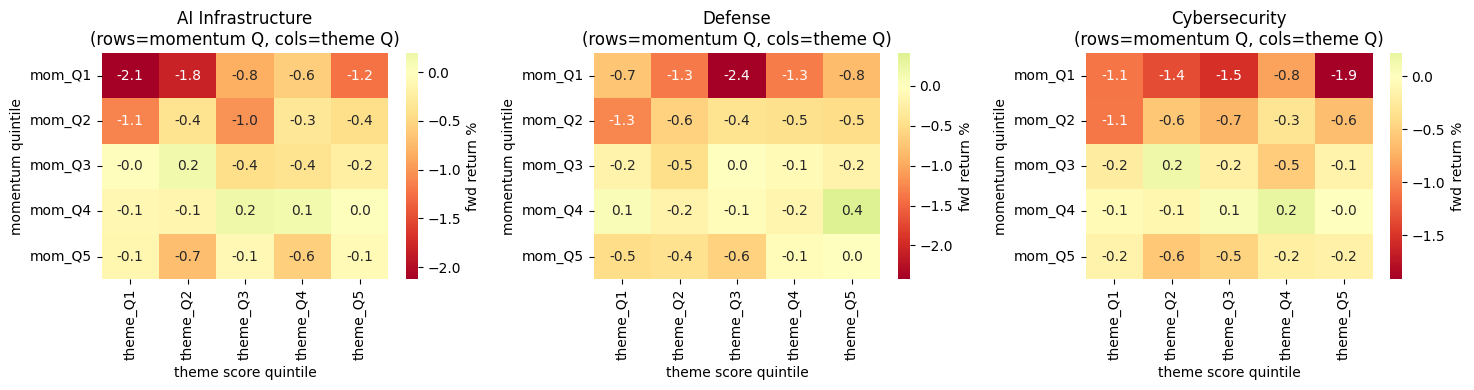

reading: if color brightens LEFT->RIGHT within each row,
theme predicts returns independent of momentum (the row).


In [30]:
# -------------------- double-sort heatmaps for a few themes --------------------
import matplotlib.pyplot as plt
import seaborn as sns

# show the double-sort grid for the 3 themes that own clean factors
show_themes = [t for t in ['AI Infrastructure', 'Defense', 'Cybersecurity'] if t in mom_results]
if show_themes:
    fig, axes = plt.subplots(1, len(show_themes), figsize=(5*len(show_themes), 4))
    if len(show_themes) == 1: axes = [axes]
    for ax, theme in zip(axes, show_themes):
        grid = mom_results[theme]['double_sort']['grid'] * 100
        sns.heatmap(grid, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax,
                    cbar_kws={'label': 'fwd return %'})
        ax.set_title(f'{theme}\n(rows=momentum Q, cols=theme Q)')
        ax.set_xlabel('theme score quintile')
        ax.set_ylabel('momentum quintile')
    plt.tight_layout()
    plt.savefig('outputs/fig_momentum_double_sort.png', dpi=150)
    plt.show()
    print('reading: if color brightens LEFT->RIGHT within each row,')
    print('theme predicts returns independent of momentum (the row).')

## Step 7.1 — Horizon Robustness of the Momentum Test

In [31]:
# -------------------- 7.1. horizon robustness --------------------
# momentum effects are horizon-sensitive. a theme whose momentum-independence
# holds at 1, 4 AND 12 weeks is far more defensible than one at 4wk alone.
# this also guards against the 4-week choice being a lucky artifact.

from src.momentum_test import horizon_robustness, robustness_verdict

robust = horizon_robustness(scores, tgt_returns, ff_factors, horizons=[1, 4, 12])
print('per-(theme,horizon) detail:')
print(robust.to_string(index=False))

print('\n' + '='*60)
print('ROBUSTNESS VERDICT (does momentum-independence hold across horizons?)')
print('='*60)
verdict = robustness_verdict(robust)
print(verdict.to_string(index=False))
verdict

per-(theme,horizon) detail:
            theme  horizon_wk  A_spread_%  B_joint_t  C_alpha_t
AI Infrastructure           1        0.08       1.04       0.37
AI Infrastructure           4        0.31       1.27       0.37
AI Infrastructure          12        0.84       2.00       0.37
     Agribusiness           1       -0.14      -1.48      -2.78
     Agribusiness           4       -0.64      -1.95      -2.78
     Agribusiness          12       -1.65      -2.59      -2.78
     Clean Energy           1       -0.10      -0.94      -2.54
     Clean Energy           4       -0.48      -1.26      -2.54
     Clean Energy          12       -1.19      -1.60      -2.54
Critical Minerals           1       -0.20      -1.18      -2.97
Critical Minerals           4       -0.80      -1.51      -2.97
Critical Minerals          12       -2.15      -1.95      -2.97
    Cybersecurity           1       -0.02      -0.21       0.57
    Cybersecurity           4       -0.05       0.08       0.57
    Cybersec

,theme,n_horizons_significant,min_joint_t,max_joint_t,verdict
0,AI Infrastructure,1/3,1.04,2.00,PARTIAL (some horizons)
1,Agribusiness,0/3,-2.59,-1.48,NEGATIVE (momentum-contaminated)
2,Clean Energy,0/3,-1.60,-0.94,NULL (no independent signal)
3,Critical Minerals,0/3,-1.95,-1.18,NULL (no independent signal)
4,Cybersecurity,0/3,-0.21,0.23,NULL (no independent signal)
5,Defense,0/3,0.76,1.42,NULL (no independent signal)
6,Fintech,0/3,-1.12,-0.96,NULL (no independent signal)
7,Robotics & AI,0/3,0.35,0.63,NULL (no independent signal)
8,Timber & Forestry,0/3,-1.59,-1.05,NULL (no independent signal)
9,US Infrastructure,3/3,3.14,5.35,ROBUST (all horizons)


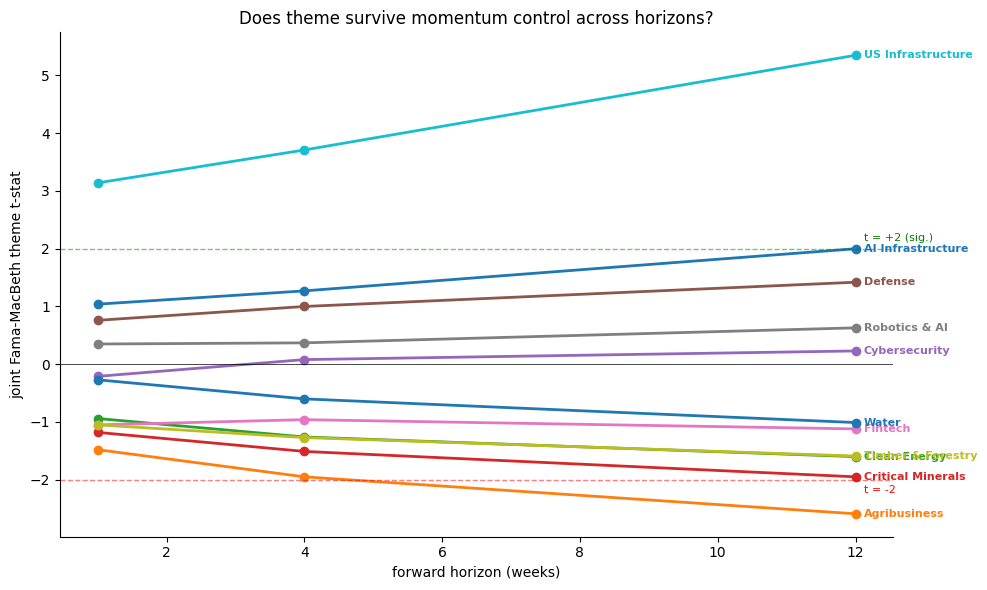

In [32]:
# -------------------- joint t-stat across horizons (line plot) --------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for theme, g in robust.groupby('theme'):
    g = g.sort_values('horizon_wk')
    line, = ax.plot(g['horizon_wk'], g['B_joint_t'], marker='o', linewidth=2)
    last = g.iloc[-1]
    ax.annotate(theme, (last['horizon_wk'], last['B_joint_t']),
                textcoords='offset points', xytext=(6, 0), fontsize=8,
                color=line.get_color(), fontweight='bold', va='center')

ax.axhline(2.0, color='green', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(-2.0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)

xmax = robust['horizon_wk'].max()
ax.annotate('t = +2 (sig.)', (xmax, 2.0), textcoords='offset points', xytext=(6, 4),
            fontsize=8, color='green', va='bottom')
ax.annotate('t = -2', (xmax, -2.0), textcoords='offset points', xytext=(6, -4),
            fontsize=8, color='red', va='top')

ax.set_xlabel('forward horizon (weeks)')
ax.set_ylabel('joint Fama-MacBeth theme t-stat')
ax.set_title('Does theme survive momentum control across horizons?')
plt.tight_layout()
plt.savefig('outputs/fig_momentum_horizon.png', dpi=150)
plt.show()

### Commit to Git

In [33]:

%cd "C:\Users\aamin\Thematic Engine"

!git remote remove origin
!git remote add origin https://github.com/AA-mini/Thematic-Engine-Paper.git
!git add .
!git commit -m "update project files"
!git branch -M master
!git push -u origin master



C:\Users\aamin\Thematic Engine


[master f955cf7] update project files
 23 files changed, 1849 insertions(+), 2094 deletions(-)
 create mode 100644 report/ThemeCloner_Draft_v4.docx
 create mode 100644 report/ThemeCloner_Draft_v4.pdf
 create mode 100644 report/ThemeCloner_Draft_v4_AA.docx
branch 'master' set up to track 'origin/master'.


To https://github.com/AA-mini/Thematic-Engine-Paper.git
   77ff134..f955cf7  master -> master
